# 23CSE301 Machine Learning Capstone — Classification (Review 1)

## Dataset: Bank Marketing (`bank-additional-full.csv`)

### Review 1 Scope
This notebook implements **Classification Part A** for Review 1:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier (SVC)

### Problem Statement
Predict whether a client will subscribe to a term deposit (`y = yes/no`) using demographic, financial, campaign, and economic attributes.

### Important modeling decision
The feature `duration` is excluded from the predictive feature set because call duration is only known after the contact interaction. Keeping it would make a pre-contact prediction problem unrealistic and can introduce target leakage.

**Notebook policy:** every required metric, table, confusion matrix, ROC curve, and plot is displayed directly in this notebook. No separate result files are required.

## 1. Imports and Reproducibility

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

## 2. Load Dataset
The loader checks common locations so the notebook works either from the repository root/notebooks folder or when the CSV is kept beside the notebook.

In [2]:
possible_paths = [
    "../data/bank-additional-full.csv",
    "data/bank-additional-full.csv",
    "bank-additional-full.csv",
]

data_path = next((p for p in possible_paths if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(
        "bank-additional-full.csv was not found. Place it in the data/ folder or beside the notebook."
    )

df = pd.read_csv(data_path, sep=";")

print(f"Loaded dataset from: {data_path}")
print(f"Dataset shape: {df.shape}")
display(df.head())

Loaded dataset from: bank-additional-full.csv
Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Dataset Audit
Report the dataset shape, data types, missing values, unique values, duplicates, and target distribution as required by the capstone rubric.

In [3]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

missing_table = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Count": df.isna().sum().values,
    "Missing %": (df.isna().mean().values * 100).round(2),
    "Unique Values": df.nunique(dropna=False).values,
}).sort_values(["Missing Count", "Feature"], ascending=[False, True])

display(missing_table)

print("Duplicate rows:", df.duplicated().sum())
print("\nTarget value counts:")
display(df["y"].value_counts().rename_axis("y").reset_index(name="Count"))

print("\nTarget percentages:")
display((df["y"].value_counts(normalize=True) * 100).round(2).rename_axis("y").reset_index(name="Percentage"))

Shape: (41188, 21)

Data types:


,dtype
age,int64
job,str
marital,str
education,str
default,str
housing,str
loan,str
contact,str
month,str
day_of_week,str


,Feature,Data Type,Missing Count,Missing %,Unique Values
0,age,int64,0,0.0,78
11,campaign,int64,0,0.0,42
17,cons.conf.idx,float64,0,0.0,26
16,cons.price.idx,float64,0,0.0,26
7,contact,str,0,0.0,2
9,day_of_week,str,0,0.0,5
4,default,str,0,0.0,3
10,duration,int64,0,0.0,1544
3,education,str,0,0.0,8
15,emp.var.rate,float64,0,0.0,10


Duplicate rows: 12

Target value counts:


,y,Count
0,no,36548
1,yes,4640



Target percentages:


,y,Percentage
0,no,88.73
1,yes,11.27


### Dataset Audit Observation

The dataset holds 41,188 rows and 21 columns, of which 10 are numeric and 11 are categorical (stored as `object`). A literal `isna()` check returns **zero** missing values everywhere, but this is misleading and is investigated properly in Section 10.1: six categorical columns encode missingness as the string `"unknown"`, which pandas counts as a valid category. `default` is the worst affected at 20.87%.

Twelve exact duplicate rows are present. That count rises sharply once `duration` is dropped for leakage reasons (Section 11), because `duration` was frequently the only column separating otherwise identical customer records.

The target is strongly imbalanced: 36,548 `no` against 4,640 `yes`, i.e. 88.73% versus 11.27%, a ratio of roughly 7.9 : 1. This single fact shapes every evaluation decision in this notebook — accuracy is not a sufficient metric on its own, the train/test split must be stratified, `class_weight="balanced"` is used wherever the estimator supports it, and model selection is driven by ROC-AUC and minority-class recall rather than by accuracy or weighted F1 alone. Section 5 quantifies the imbalance and Section 17.1 shows the concrete consequence of ignoring it.


## 4. Descriptive Statistics

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Target Distribution
The target `y` is binary. Show both counts and percentages.

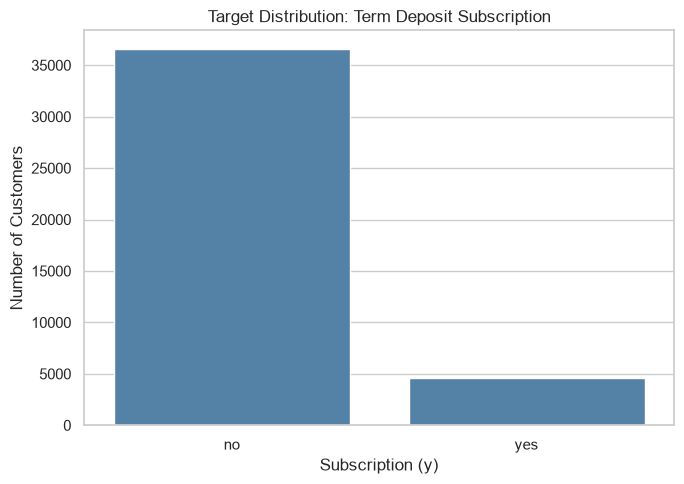

In [5]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="y", order=["no", "yes"], color="steelblue")
ax.set_title("Target Distribution: Term Deposit Subscription")
ax.set_xlabel("Subscription (y)")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [6]:
target_counts = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_pct.round(2)
}).reindex(["no", "yes"])

display(target_summary)
imbalance_ratio = target_counts["no"] / target_counts["yes"]
print(f"Majority:minority (no:yes) ratio ≈ {imbalance_ratio:.1f} : 1")


,Count,Percentage
y,,
no,36548,88.73
yes,4640,11.27


Majority:minority (no:yes) ratio ≈ 7.9 : 1


### Target Distribution Observation
The table above confirms strong class imbalance: on `bank-additional-full.csv` roughly 88-89% of customers did **not** subscribe (`no`) and only about 11-12% did (`yes`), an imbalance ratio of roughly 8:1. This matters for evaluation in three ways:

1. **Accuracy is misleading.** A trivial classifier that always predicts `no` would score close to 88-89% accuracy while never identifying a single subscriber — the metric would look strong despite being useless for the bank's actual goal (finding likely subscribers).
2. **Precision and recall on the minority class matter most.** Recall on `yes` tells the bank what fraction of genuine subscribers its model would catch; precision on `yes` tells it how many of the flagged customers are worth contacting. Weighted F1 balances both classes but can still mask poor minority-class performance, so per-class precision/recall (visible in the confusion matrix) is reported alongside it.
3. **ROC-AUC is threshold-independent**, so it evaluates how well each model ranks `yes` customers above `no` customers across all decision thresholds, rather than only at the default 0.5 cut-off — useful here because the bank can choose to move that threshold to trade off how many customers get called.

This is also why `class_weight="balanced"` is used for Logistic Regression, Decision Tree and SVC below, and why the comparison table is ranked by weighted F1 rather than accuracy.


## 6. Numerical Feature Exploration

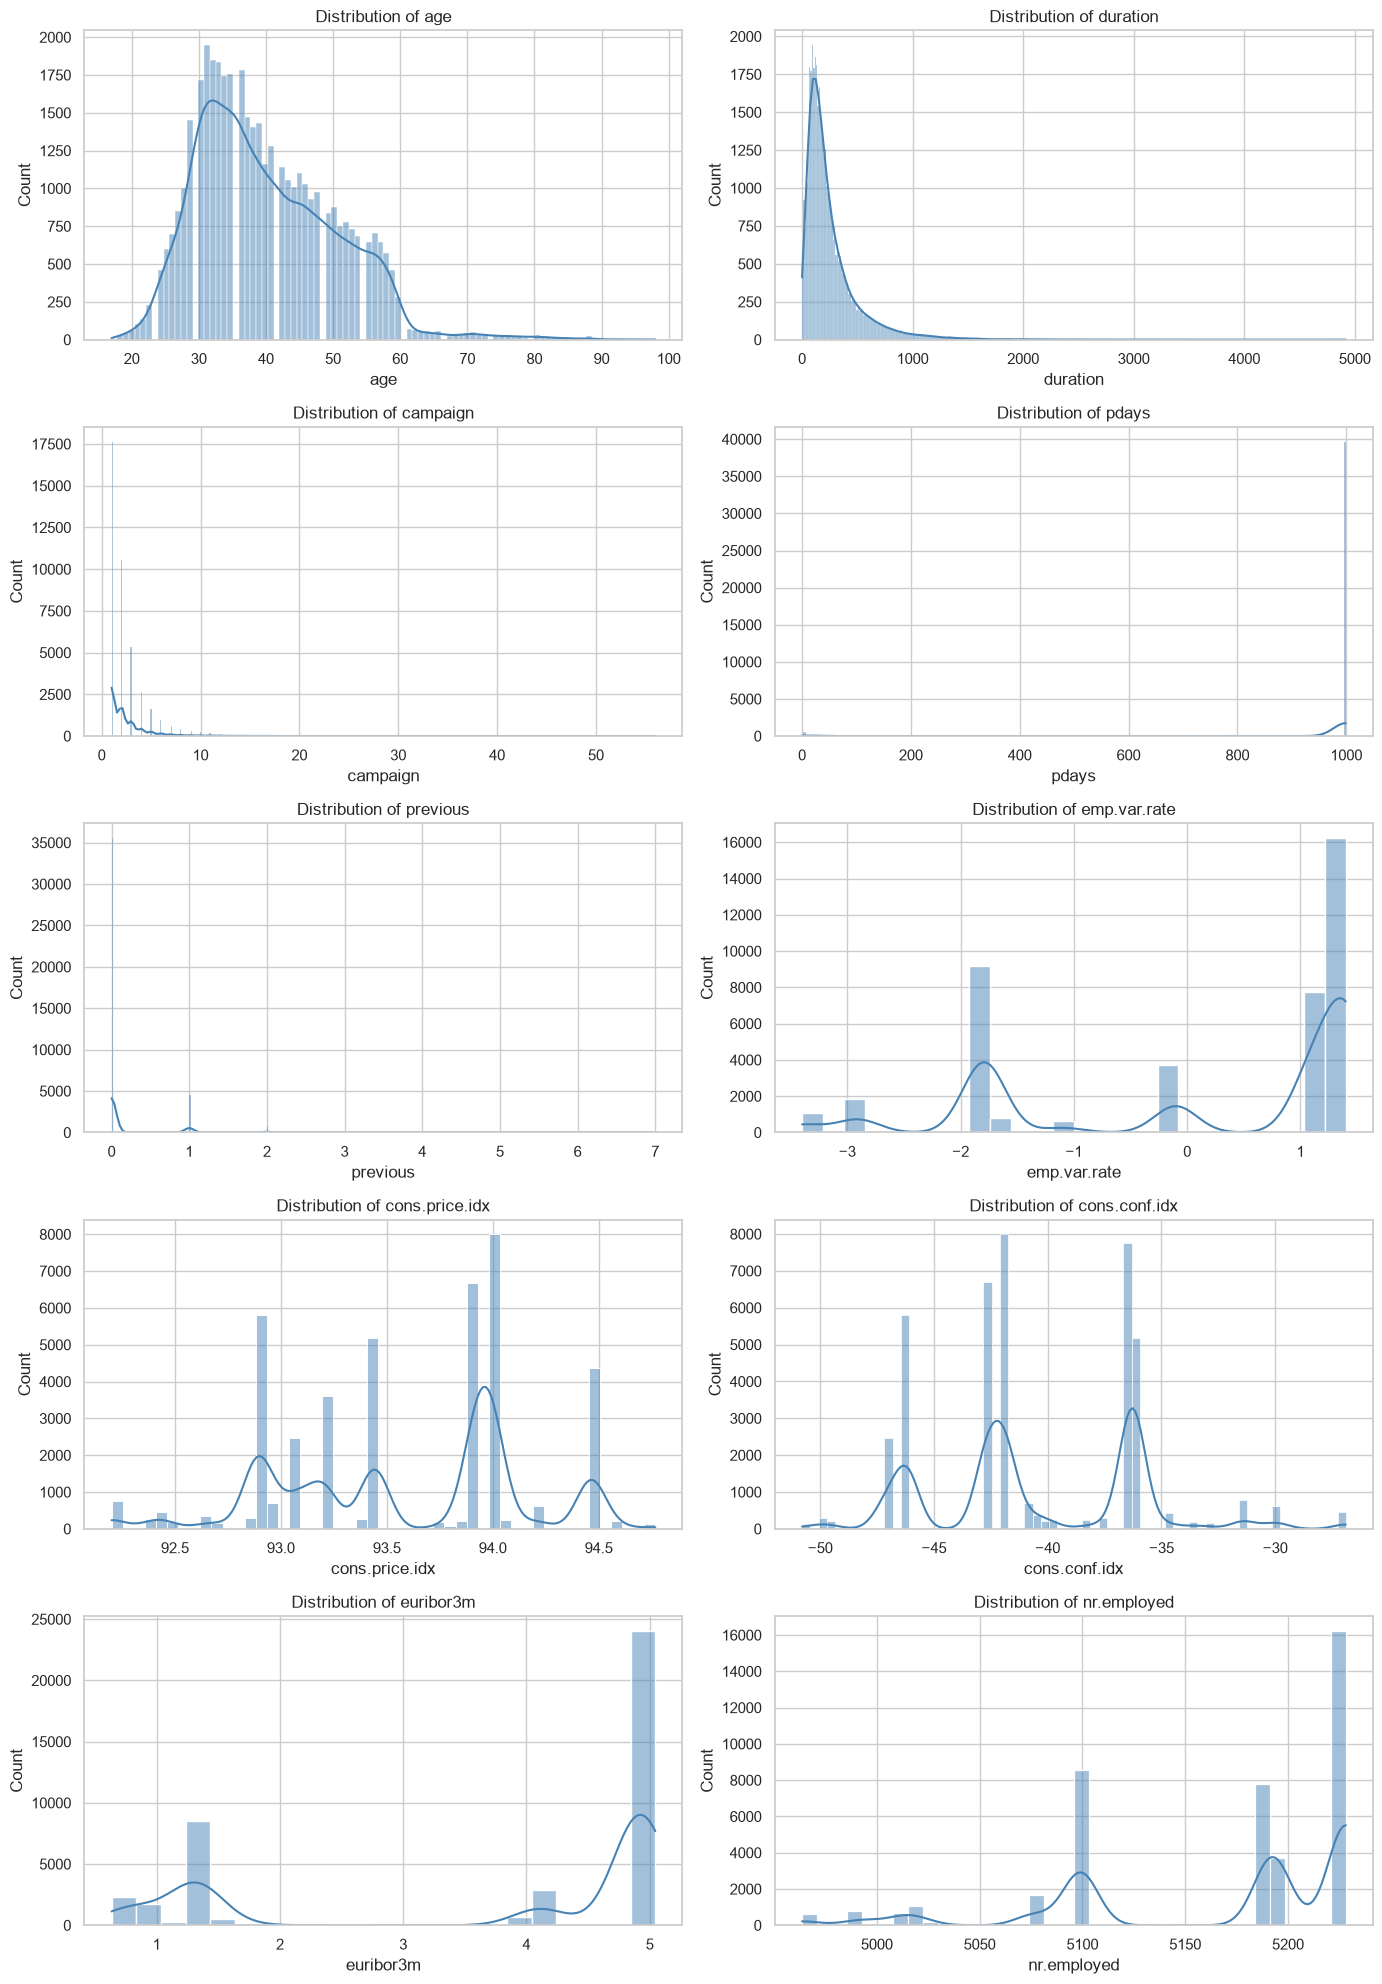

In [7]:
numerical_cols_all = df.select_dtypes(include=np.number).columns.tolist()

ncols = 2
nrows = int(np.ceil(len(numerical_cols_all) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numerical_cols_all):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[len(numerical_cols_all):]:
    ax.remove()

plt.tight_layout()
plt.show()

## 7. Numerical Features vs Target
Show examples of numerical variables across subscription classes. These plots are exploratory and do not establish causation.

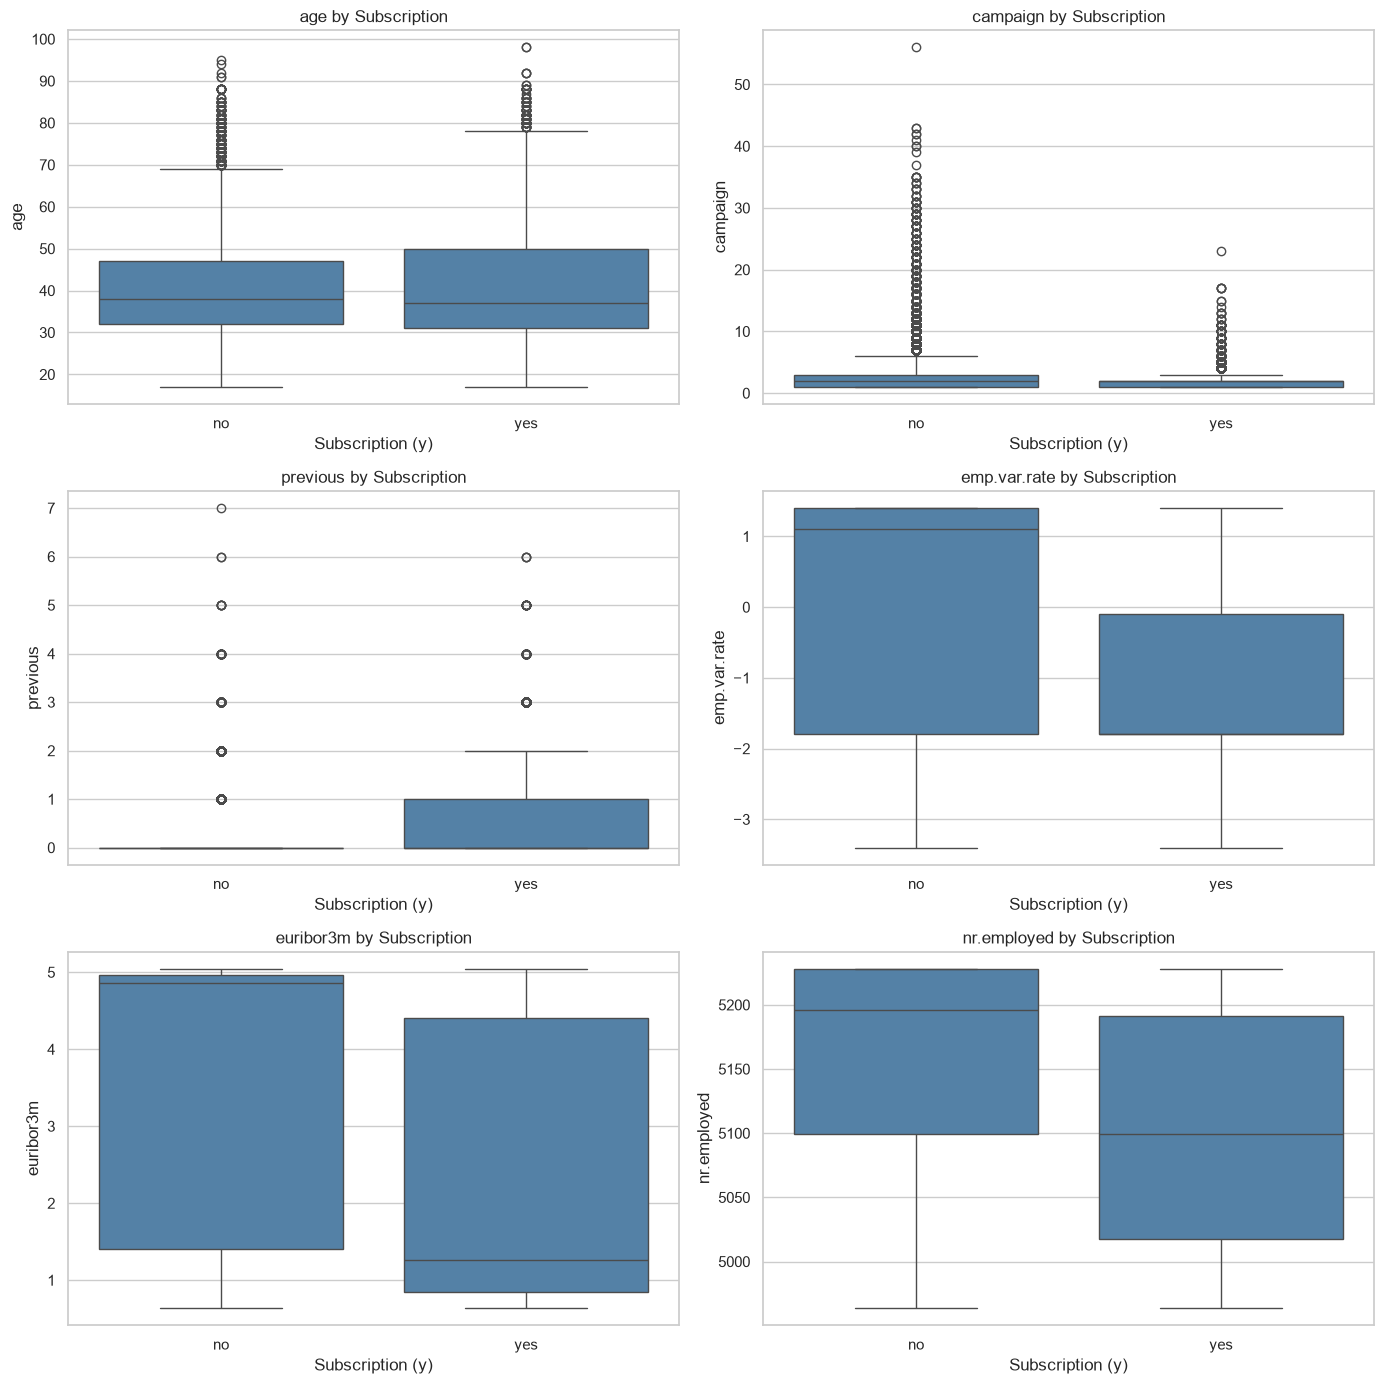

In [8]:
plot_cols = ["age", "campaign", "previous", "emp.var.rate", "euribor3m", "nr.employed"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.ravel()
for ax, col in zip(axes, plot_cols):
    sns.boxplot(data=df, x="y", y=col, order=["no", "yes"], ax=ax, color="steelblue")
    ax.set_title(f"{col} by Subscription")
    ax.set_xlabel("Subscription (y)")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

### 7.1 Feature-Pair Scatter Plots (supplementary EDA)
The two scatter plots below place two numerical features on the axes and colour each point by the
subscription outcome. They are useful for seeing how *pairs* of features co-vary with the target, but
because `y` is binary they are **supplementary** EDA — the explicit feature-vs-target scatter/jitter
plots required by rubric item A2 are in Section 7.2.


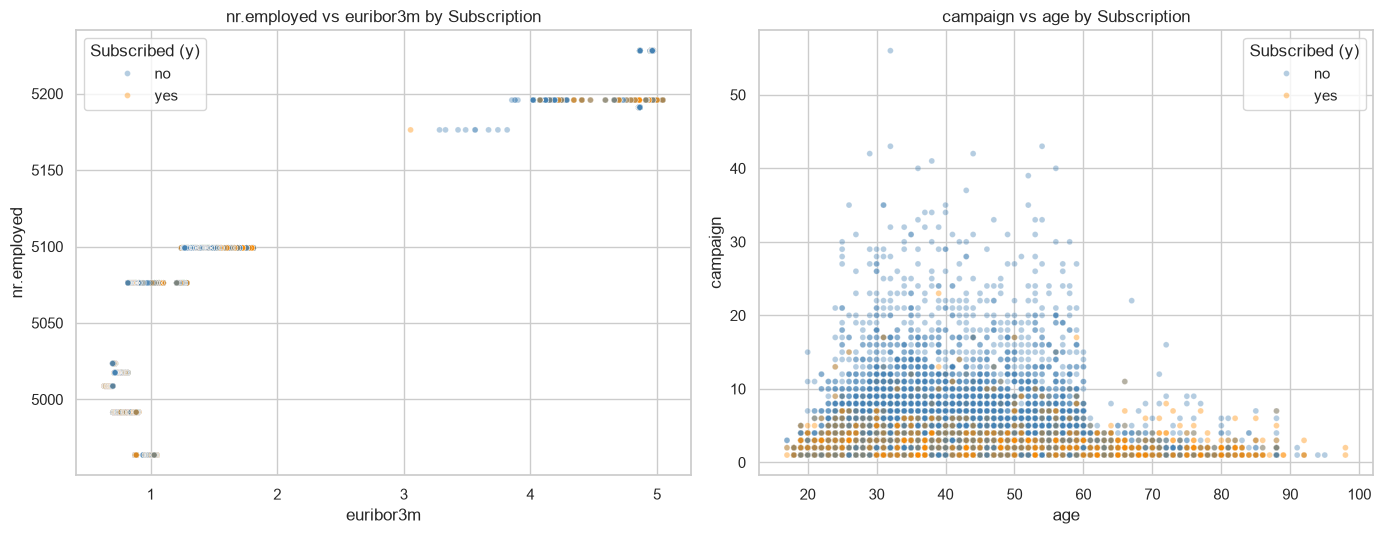

In [9]:
scatter_pairs = [
    ("euribor3m", "nr.employed"),
    ("age", "campaign"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
palette = {"no": "steelblue", "yes": "darkorange"}

for ax, (xcol, ycol) in zip(axes, scatter_pairs):
    sns.scatterplot(
        data=df,
        x=xcol,
        y=ycol,
        hue="y",
        hue_order=["no", "yes"],
        palette=palette,
        alpha=0.4,
        s=18,
        ax=ax,
    )
    ax.set_title(f"{ycol} vs {xcol} by Subscription")
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.legend(title="Subscribed (y)")

plt.tight_layout()
plt.show()


**Observation.** `euribor3m` and `nr.employed` move almost in lockstep (both track the macroeconomic cycle), and `yes` points concentrate at the *low* end of both axes — customers were more likely to subscribe during periods of low interest rates and lower employment, i.e. when a term deposit was relatively more attractive and/or the bank ran more intensive campaigns during downturns. In the `age` vs `campaign` scatter, `yes` points are spread across most ages but cluster at *low* campaign counts, suggesting that customers contacted many times in the current campaign were less likely to subscribe, consistent with contact fatigue.


### 7.2 Feature vs Target Scatter / Jitter Plots
Rubric item A2 requires at least two scatter plots showing the relationship between a **feature and the
target**. The target `y` is categorical, so it is first converted to a binary indicator
(`y_binary = 1` for `yes`, `0` for `no`). Plotting a continuous feature directly against a 0/1 variable
would collapse every point onto two horizontal lines, so a small amount of vertical **jitter** is added to
the target axis. The vertical spread carries no meaning of its own — it exists purely to make the density
of points within each class visible.


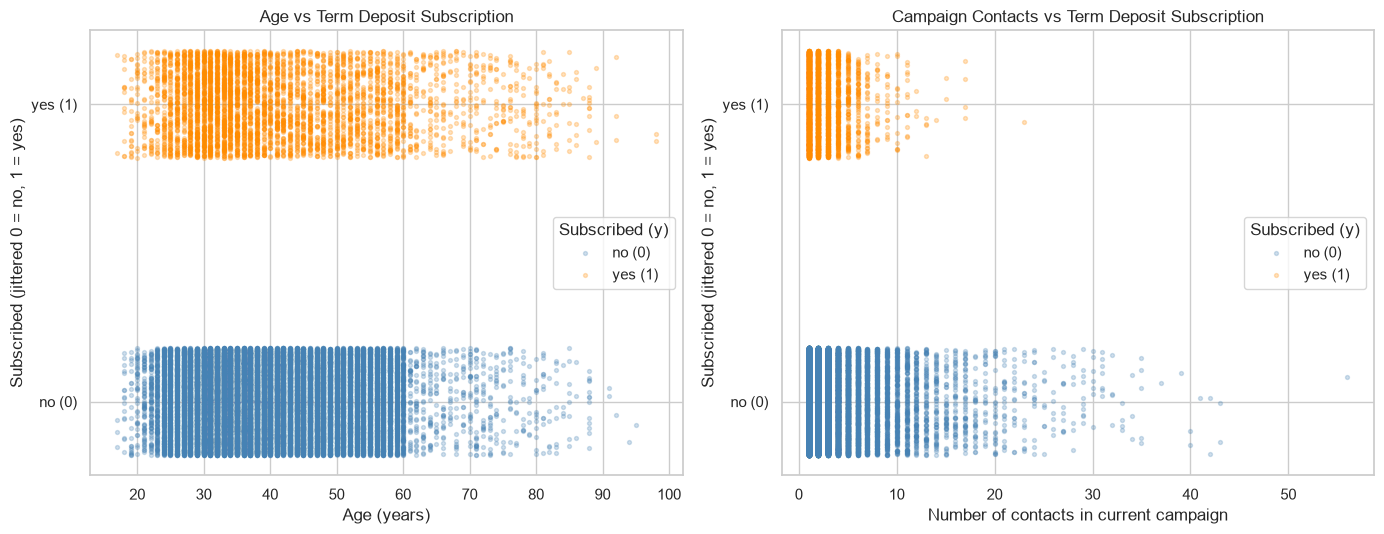

Mean/median of the two plotted features by subscription outcome:


age        campaign       
          mean median     mean median
no (0)   39.91   38.0     2.63    2.0
yes (1)  40.91   37.0     2.05    2.0

In [10]:
# 7.2 Feature-vs-target scatter/jitter plots
# Binary encoding of the categorical target for plotting purposes only.
y_binary = (df["y"] == "yes").astype(int)

rng = np.random.default_rng(RANDOM_STATE)
jitter = rng.uniform(-0.18, 0.18, size=len(df))

jitter_specs = [
    ("age", "Age (years)", "Age vs Term Deposit Subscription"),
    ("campaign", "Number of contacts in current campaign", "Campaign Contacts vs Term Deposit Subscription"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
palette = {0: "steelblue", 1: "darkorange"}

for ax, (col, xlabel, title) in zip(axes, jitter_specs):
    for class_value, label in [(0, "no (0)"), (1, "yes (1)")]:
        mask = (y_binary == class_value).to_numpy()
        ax.scatter(
            df.loc[mask, col],
            y_binary[mask] + jitter[mask],
            s=8,
            alpha=0.25,
            color=palette[class_value],
            label=label,
        )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Subscribed (jittered 0 = no, 1 = yes)")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["no (0)", "yes (1)"])
    ax.legend(title="Subscribed (y)", loc="center right")

plt.tight_layout()
plt.show()

# Companion numeric summary so the visual impression can be checked against actual values.
jitter_summary = (
    df.assign(y_binary=y_binary)
      .groupby("y_binary")[["age", "campaign"]]
      .agg(["mean", "median"])
      .round(2)
)
jitter_summary.index = ["no (0)", "yes (1)"]
print("Mean/median of the two plotted features by subscription outcome:")
display(jitter_summary)


**Observation.** The target is a categorical variable, so these plots use a **jittered categorical
scatter** representation: the y-axis holds only two real values (`0` = no, `1` = yes) and the vertical
scatter within each band is artificial jitter added so that overlapping points do not hide the density of
the data.

Read this way, the `age` panel shows subscribers spread across essentially the whole age range, with the
`yes` band visibly denser at the young and old extremes than in the middle-aged bulk — consistent with
students and retirees being over-represented among subscribers, as the `job` subscription-rate plot in
Section 8 also suggests. The `campaign` panel is more clearly separated: the `yes` band thins out very
quickly as the contact count rises, while the `no` band extends far to the right, which matches the idea
that repeatedly re-contacting the same customer yields diminishing returns.

These plots are **descriptive only**. They show association in the observed sample and do **not** imply
causation — the campaign pattern in particular is at least partly a recording artefact, since a customer
who agrees early simply stops being contacted, so a low contact count is in part a *consequence* of
subscribing rather than a cause of it. The exact numbers behind the visual impression are printed in the
accompanying summary table.


## 8. Categorical Feature Exploration
Two complementary views are produced for every categorical predictor:

* **Section 8.1 — distribution (count) plots**: how many records fall into each category. This exposes
  dominant and rare levels, which matters because a category holding only a handful of rows cannot
  support a reliable subscription-rate estimate.
* **Section 8.2 — subscription-rate plots**: the percentage of `yes` within each category. The rate is
  more informative than raw counts when the categories differ wildly in size.

Both are needed: a category can show a spectacular subscription rate purely because it contains very few
customers, and only the count plot reveals that.


### 8.1 Distribution of Each Categorical Predictor


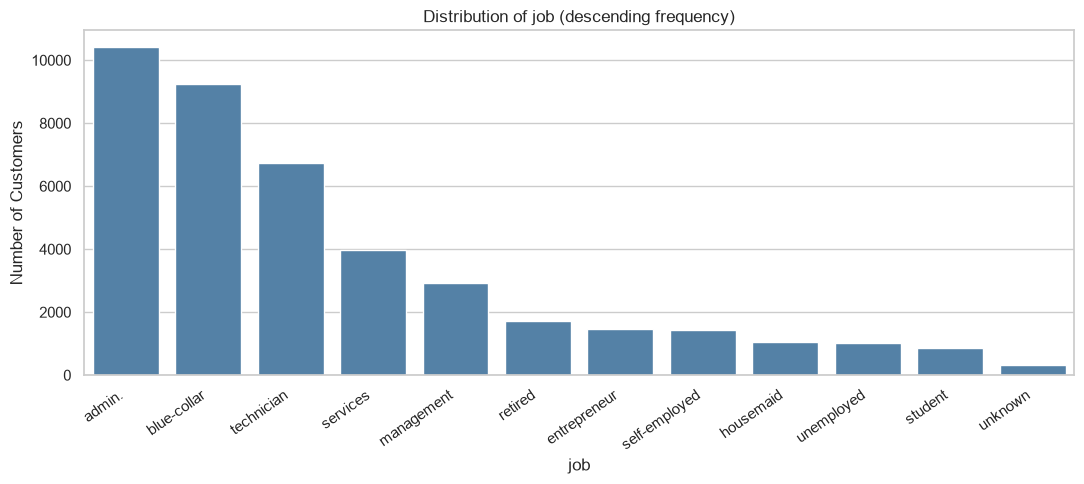

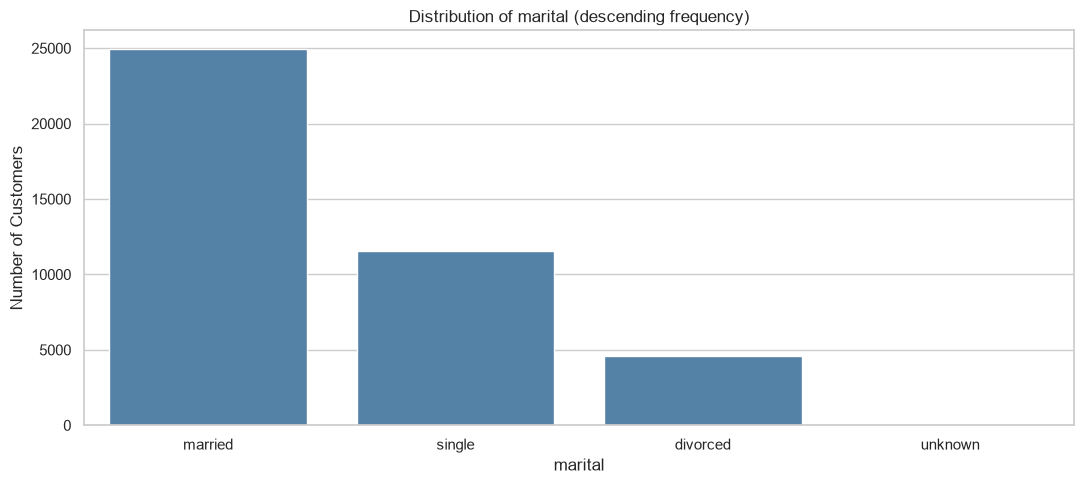

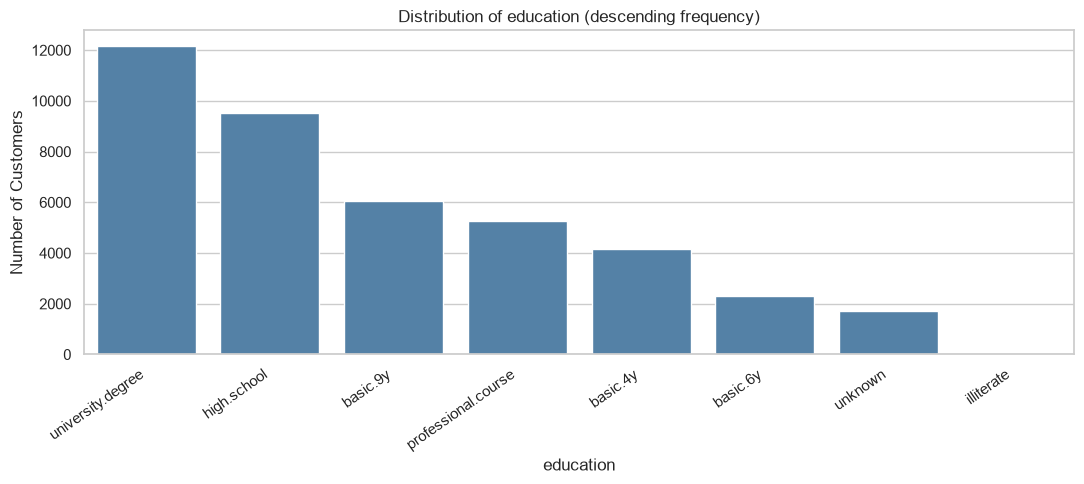

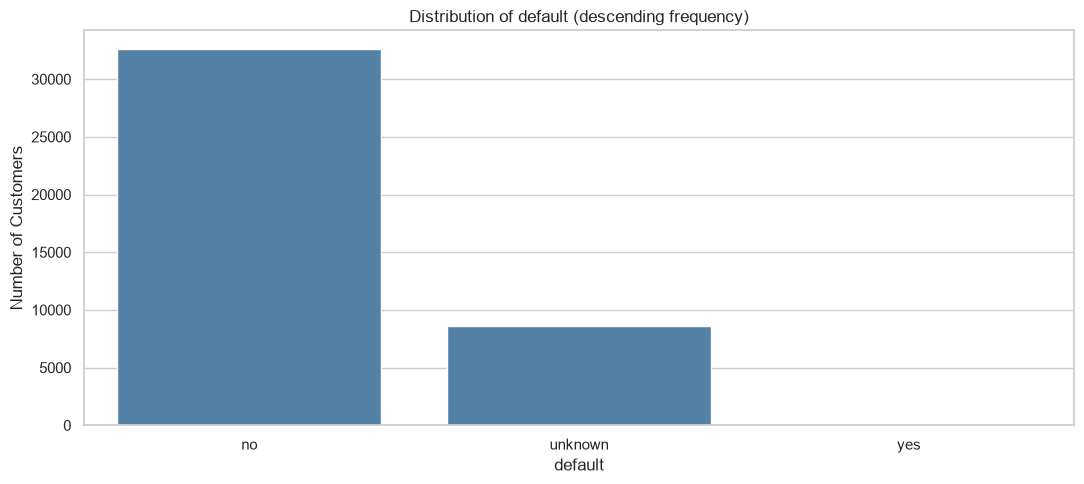

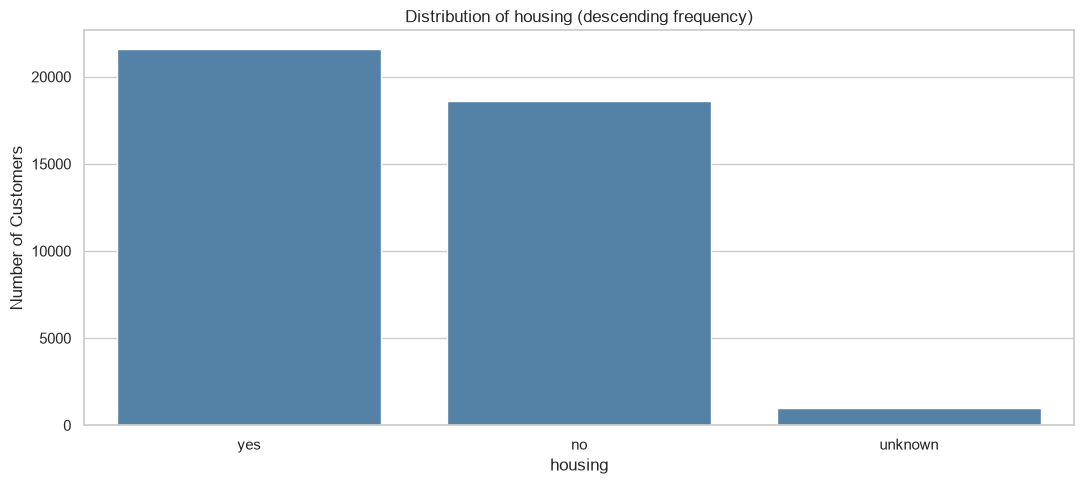

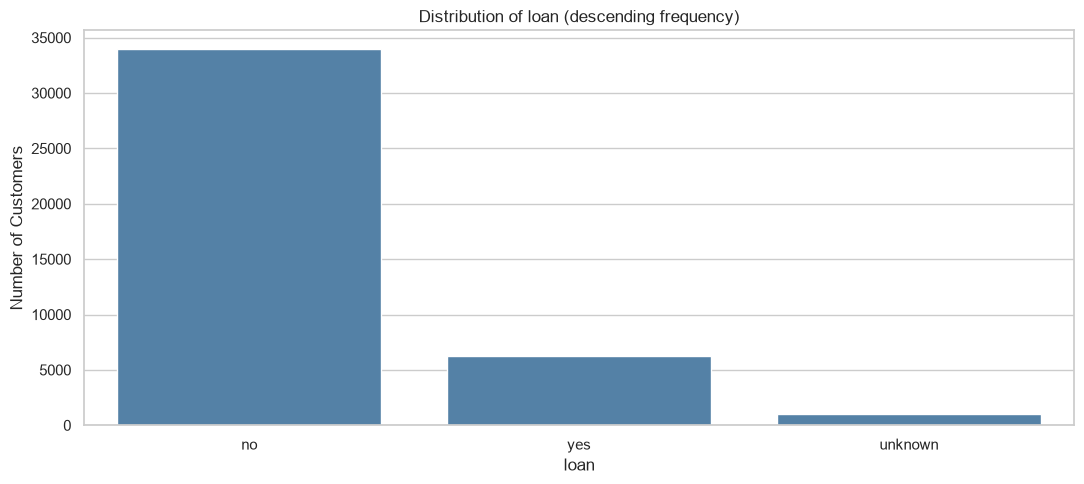

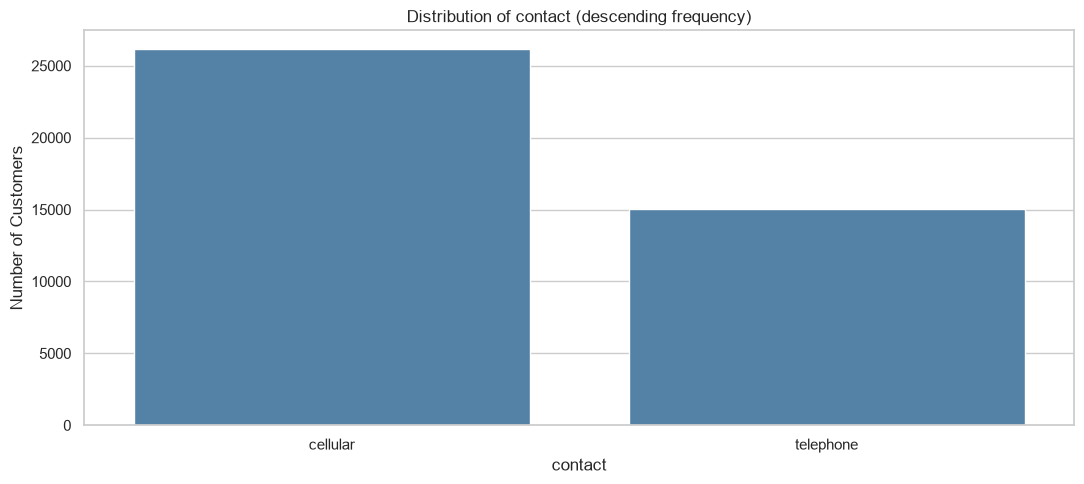

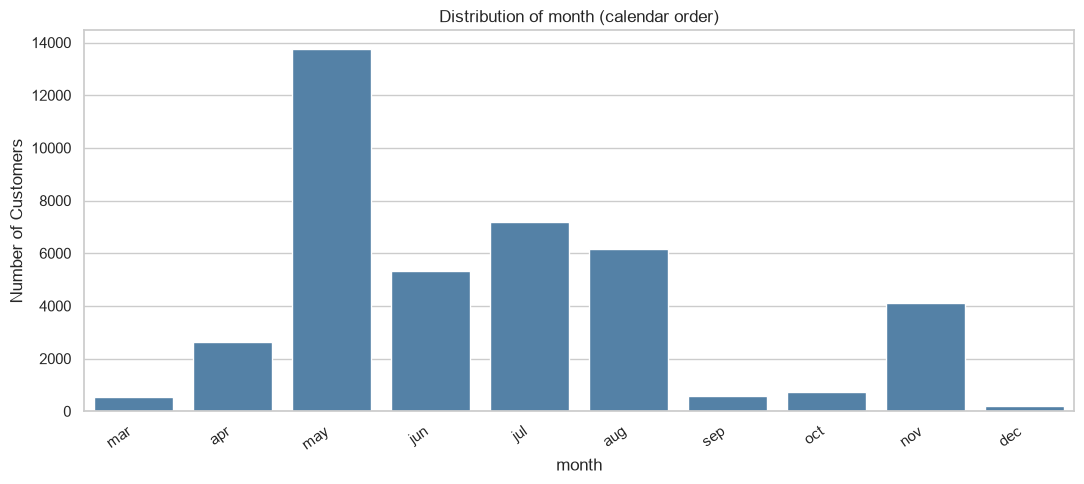

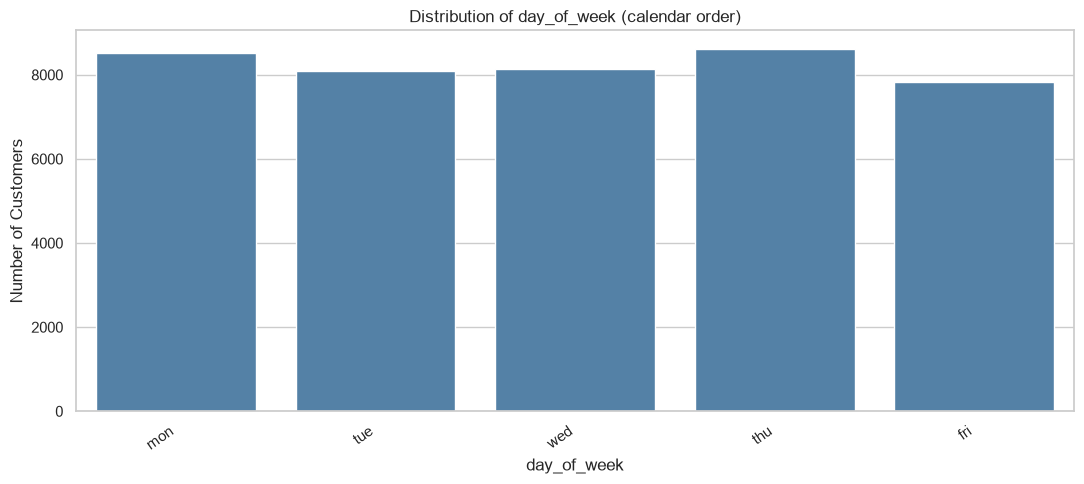

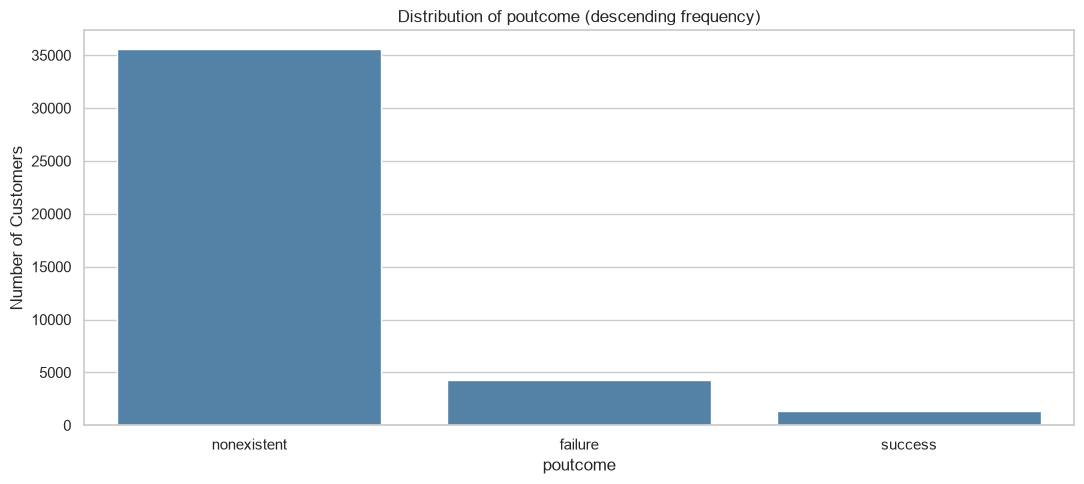

Category dominance summary:


,Feature,Levels,Largest Level,Largest Level %,Smallest Level,Smallest Level Count
0,job,12,admin.,25.30,unknown,330
1,marital,4,married,60.52,unknown,80
2,education,8,university.degree,29.54,illiterate,18
3,default,3,no,79.12,yes,3
4,housing,3,yes,52.38,unknown,990
5,loan,3,no,82.43,unknown,990
6,contact,2,cellular,63.47,telephone,15044
7,month,10,may,33.43,dec,182
8,day_of_week,5,thu,20.94,fri,7827
9,poutcome,3,nonexistent,86.34,success,1373


In [11]:
# 8.1 Count plots for every categorical predictor used in the EDA
categorical_cols_for_eda = [
    "job", "marital", "education", "default", "housing",
    "loan", "contact", "month", "day_of_week", "poutcome"
]

# Calendar / weekday variables read better in their natural order; the rest are
# ordered by frequency so the dominant and rare levels are immediately visible.
natural_orders = {
    "month": ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"],
    "day_of_week": ["mon", "tue", "wed", "thu", "fri"],
}

for col in categorical_cols_for_eda:
    if col in natural_orders:
        order = [lvl for lvl in natural_orders[col] if lvl in df[col].unique()]
        order += [lvl for lvl in df[col].unique() if lvl not in order]
        order_note = "calendar order"
    else:
        order = df[col].value_counts().index.tolist()
        order_note = "descending frequency"

    plt.figure(figsize=(11, 5))
    ax = sns.countplot(data=df, x=col, order=order, color="steelblue")
    ax.set_title(f"Distribution of {col} ({order_note})")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of Customers")
    if len(order) > 4:
        plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

# Compact numeric companion: share of the single largest level and the size of the smallest level.
dominance_rows = []
for col in categorical_cols_for_eda:
    counts = df[col].value_counts()
    dominance_rows.append({
        "Feature": col,
        "Levels": int(counts.size),
        "Largest Level": counts.index[0],
        "Largest Level %": round(counts.iloc[0] / len(df) * 100, 2),
        "Smallest Level": counts.index[-1],
        "Smallest Level Count": int(counts.iloc[-1]),
    })

print("Category dominance summary:")
display(pd.DataFrame(dominance_rows))


**Observation — what the categorical distributions reveal.** The predictors are far from uniformly
distributed, and the dominance summary quantifies it.

Several variables are dominated by a single level: `contact` is split between only two channels,
`default` is overwhelmingly `no` with a large `unknown` block and an almost empty `yes` level, and
`poutcome` is dominated by `nonexistent` because most customers were never part of a previous campaign.
`month` is severely unbalanced in the opposite direction — `may` carries the largest share of contacts
while `mar`, `sep`, `oct` and `dec` are comparatively rare, which reflects how the campaign was actually
scheduled rather than any property of the customers. `day_of_week`, by contrast, is close to even, which
makes it unlikely to carry much signal.

The rare levels matter for interpretation. Where a category holds only a few hundred records — or, in the
case of `default = yes`, a handful — any subscription rate computed for it in Section 8.2 rests on a very
small denominator and should be treated as noisy rather than as a finding. It also means one-hot encoding
will create some extremely sparse columns; these are harmless for tree and linear models but do contribute
to the dimensionality problem that hurts KNN's distance metric (discussed in Section 20).


### 8.2 Subscription Rate by Category


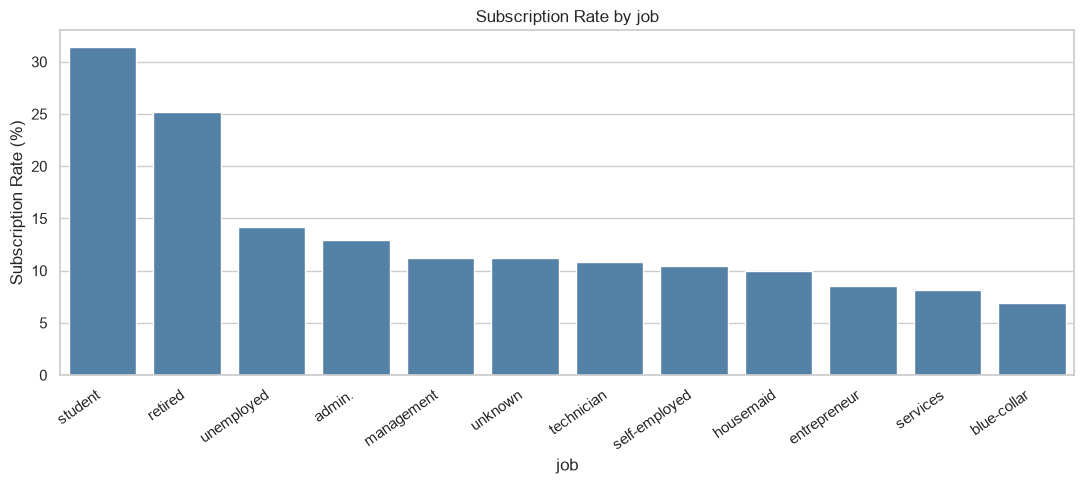

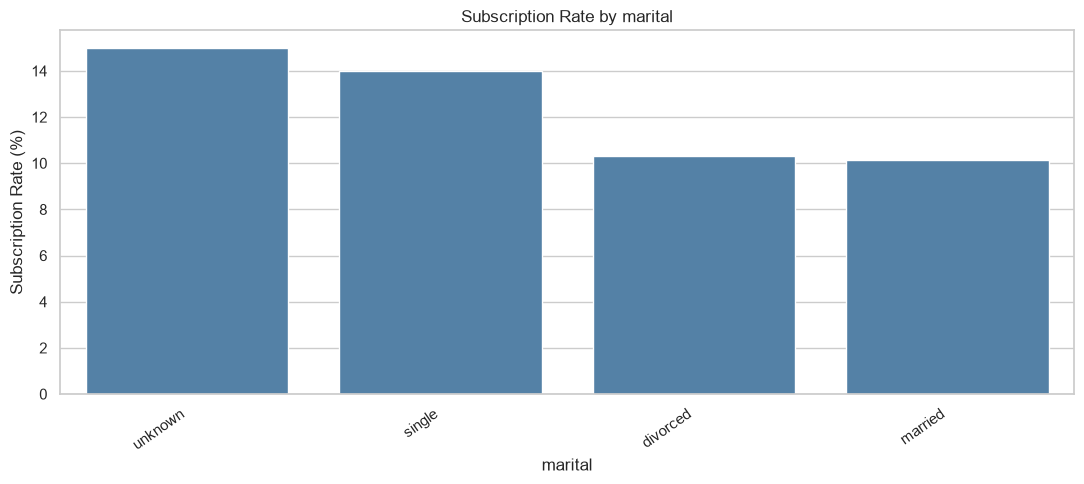

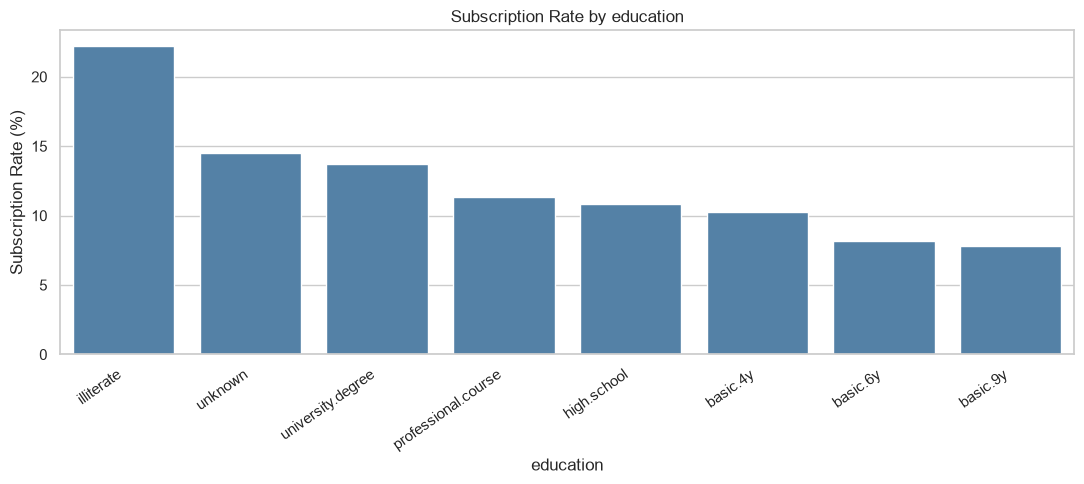

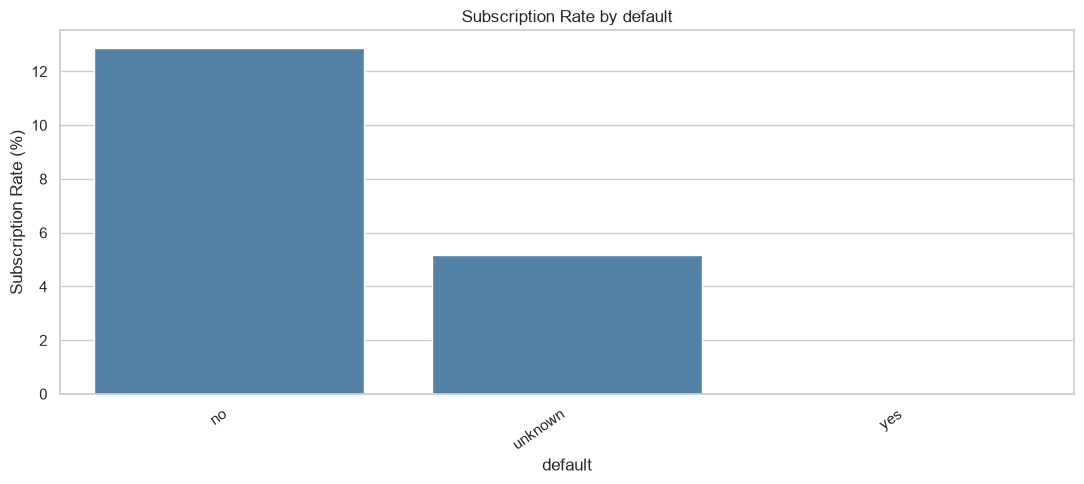

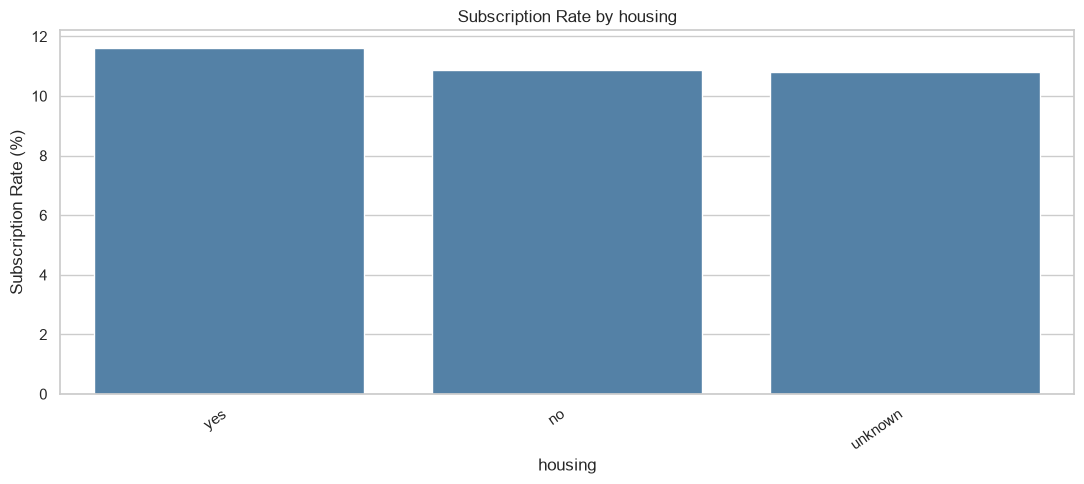

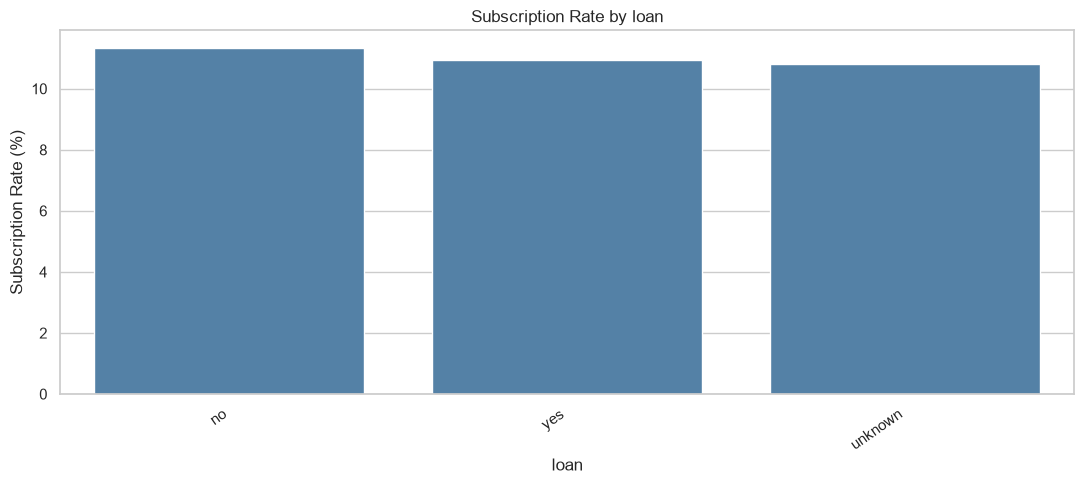

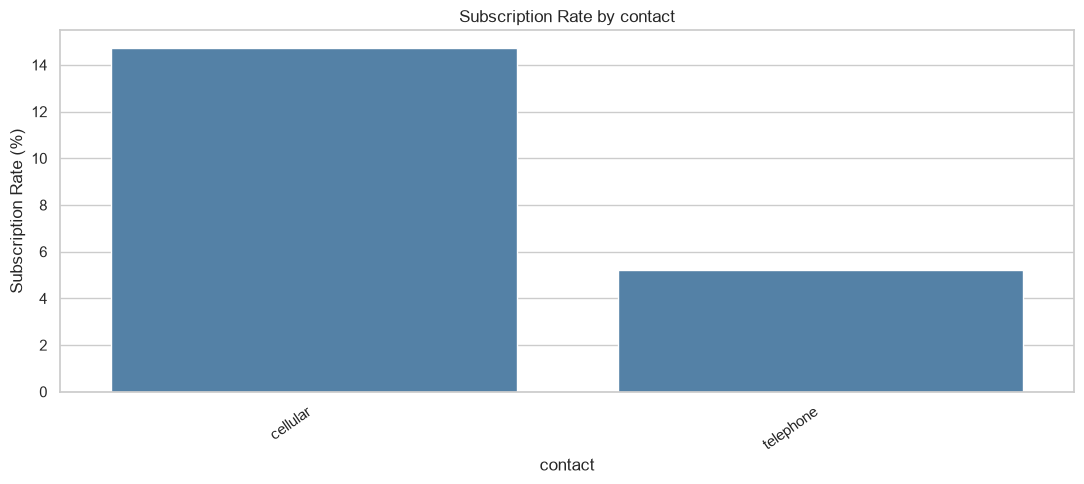

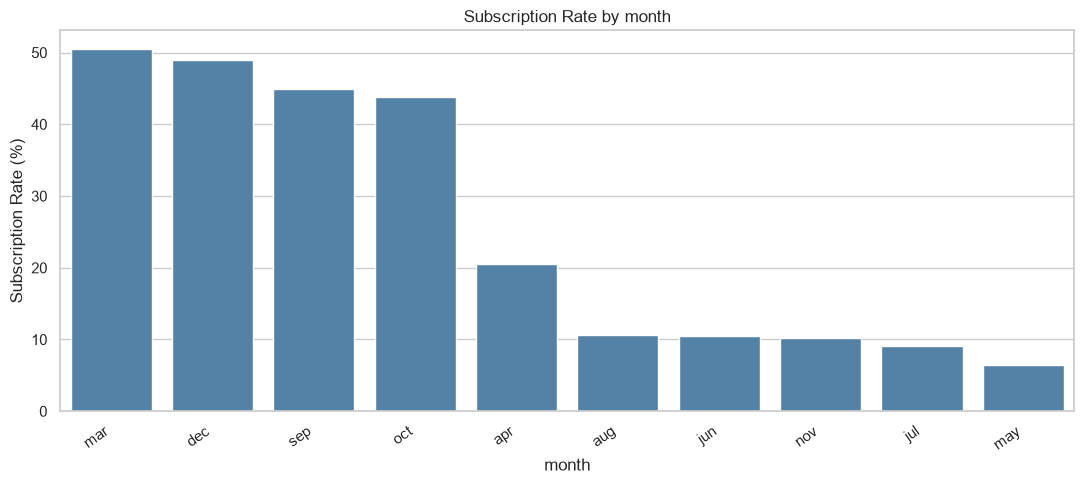

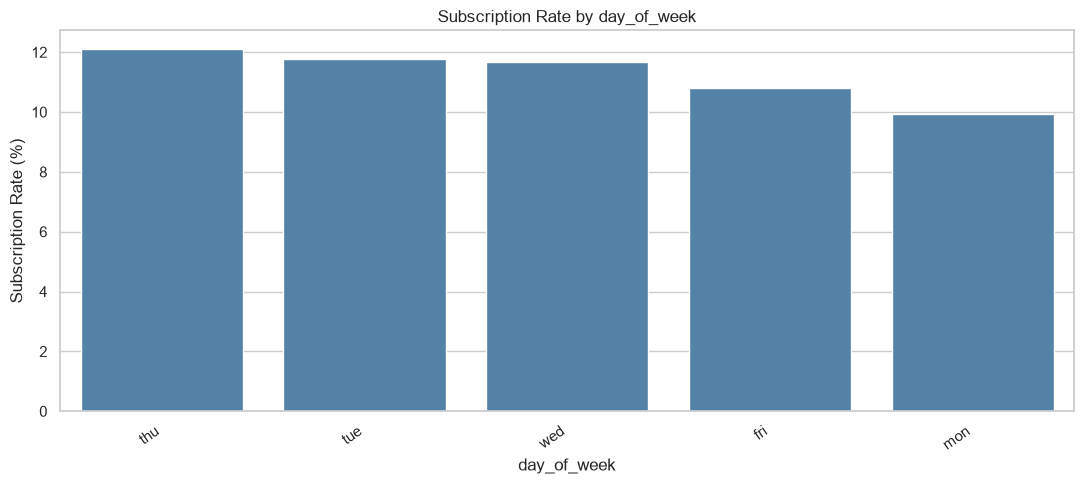

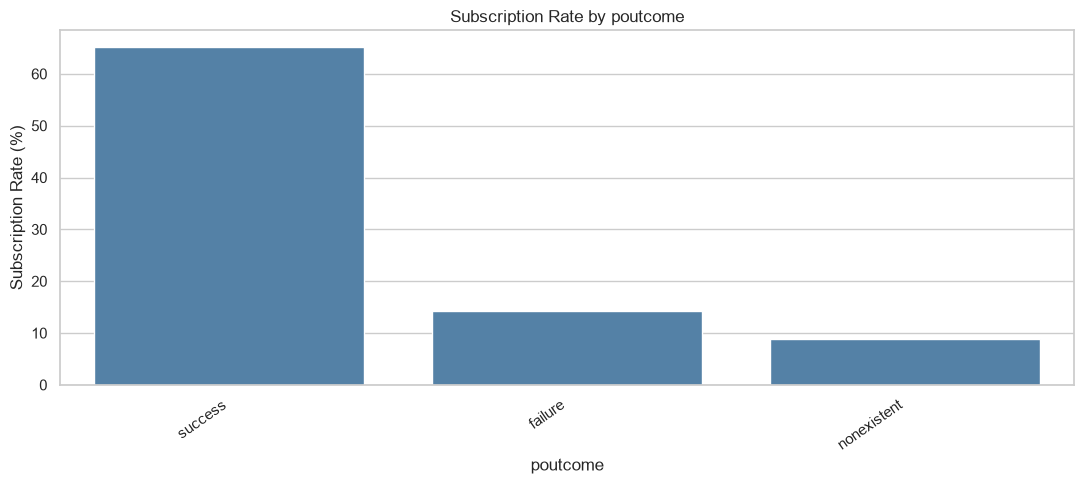

In [12]:
# 8.2 Subscription rate by category (uses the same list defined in Section 8.1)
for col in categorical_cols_for_eda:
    rate = (
        df.groupby(col, dropna=False)["y"]
          .apply(lambda s: (s == "yes").mean() * 100)
          .sort_values(ascending=False)
          .reset_index(name="Subscription Rate (%)")
    )

    plt.figure(figsize=(11, 5))
    ax = sns.barplot(data=rate, x=col, y="Subscription Rate (%)", color="steelblue")
    ax.set_title(f"Subscription Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Subscription Rate (%)")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

## 9. Correlation Heatmap
Use numerical variables to inspect pairwise linear association. Correlation is descriptive and does not imply causation.

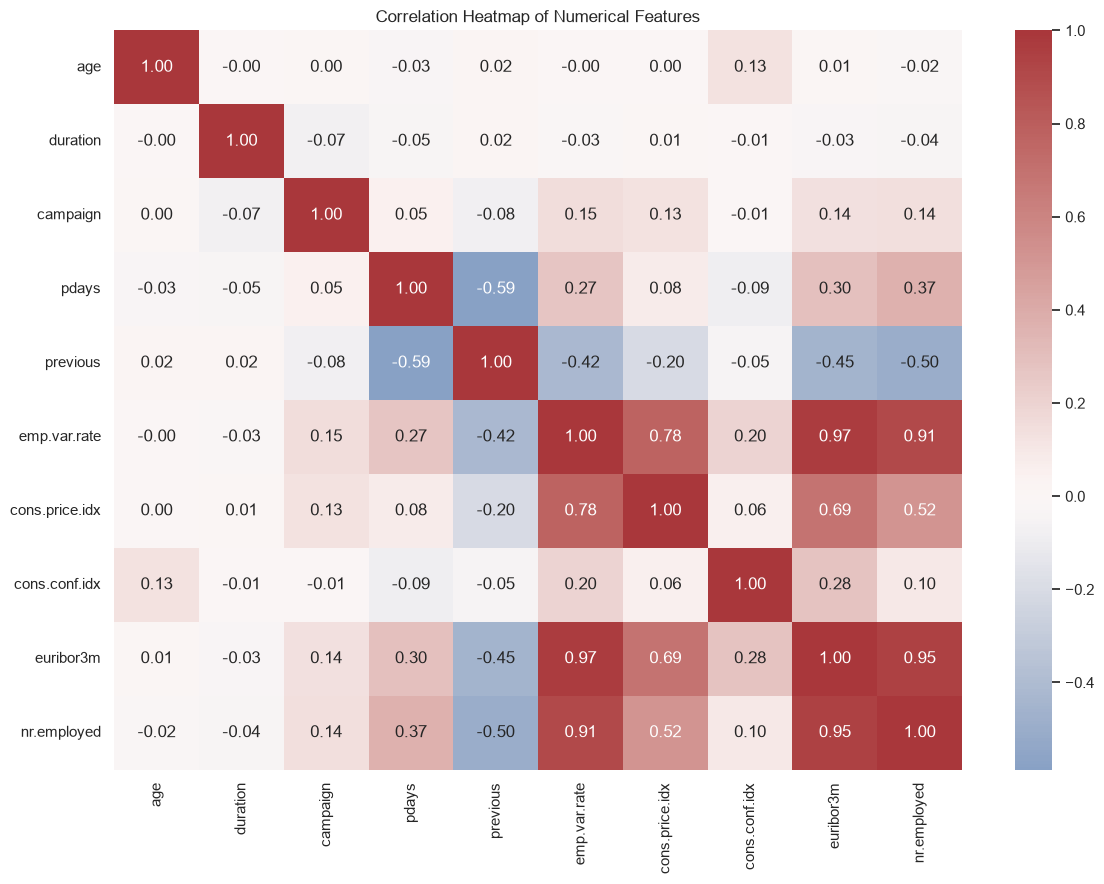

In [13]:
plt.figure(figsize=(12, 9))
corr = df[numerical_cols_all].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## 10. Duplicate and Data-Quality Checks

In [14]:
print(f"Duplicate rows before cleaning: {df.duplicated().sum()}")

print("\nUnique values in key categorical columns:")
for col in ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome", "y"]:
    print(f"{col}: {sorted(df[col].dropna().unique().tolist())}")

Duplicate rows before cleaning: 12

Unique values in key categorical columns:
job: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
marital: ['divorced', 'married', 'single', 'unknown']
education: ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']
default: ['no', 'unknown', 'yes']
housing: ['no', 'unknown', 'yes']
loan: ['no', 'unknown', 'yes']
contact: ['cellular', 'telephone']
month: ['apr', 'aug', 'dec', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
day_of_week: ['fri', 'mon', 'thu', 'tue', 'wed']
poutcome: ['failure', 'nonexistent', 'success']
y: ['no', 'yes']


### 10.1 `"unknown"` as a De Facto Missing-Value Category
`bank-additional-full.csv` has zero literal `NaN` values, but several categorical columns (`job`, `marital`, `education`, `default`, `housing`, `loan`) encode missingness as the string `"unknown"`. This is a real missing-value problem that a raw `isna()` check does not catch, so it is quantified and a handling strategy is chosen explicitly below.


In [15]:
unknown_cols = ["job", "marital", "education", "default", "housing", "loan"]

unknown_report = pd.DataFrame({
    "Unknown Count": [(df[c] == "unknown").sum() for c in unknown_cols],
    "Unknown %": [round((df[c] == "unknown").mean() * 100, 2) for c in unknown_cols],
}, index=unknown_cols).sort_values("Unknown %", ascending=False)

display(unknown_report)


,Unknown Count,Unknown %
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


**Strategy (justified).** `unknown` is retained as an explicit categorical level rather than replacing
it with the mode. This preserves the information that the original value was unavailable and avoids
imposing an unsupported assumption that the missing value should have the same distribution as the most
common category.

Concretely, `OneHotEncoder` treats `unknown` as a normal level, so each model can learn its own
coefficient or split for it, and the fact that a value was not recorded remains available to the model
instead of being silently overwritten. `default` is the column where this matters most simply because it
has by far the highest `unknown` rate.

**A note on terminology.** This notebook deliberately does *not* label these values as MNAR
(missing-not-at-random). Naming a missingness mechanism is a claim about *why* the values are absent, and
establishing it would require a missingness-mechanism analysis that is not performed here. Retaining
`unknown` as its own level is the safer choice precisely because it does not depend on knowing the
mechanism: it is valid whether the values are missing at random or not, whereas mode imputation would only
be defensible under an assumption this notebook has not tested.


### 10.2 Outlier Audit — All Numerical Features
Every numerical column in the dataset is screened with the IQR rule: a value is flagged when it falls
below $Q1 - 1.5\times\text{IQR}$ or above $Q3 + 1.5\times\text{IQR}$. The table reports $Q1$, $Q3$, the
IQR, both bounds, the flagged count and the flagged percentage for each feature. No column is excluded
from the audit — `duration` and `pdays` are screened alongside the rest and then discussed separately,
because excluding a column from the audit and excluding it from *treatment* are different decisions.


In [16]:
# 10.2 IQR screening applied to every numerical feature in the dataset
numerical_cols_audit = df.select_dtypes(include=np.number).columns.tolist()

def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_rows = []
for col in numerical_cols_audit:
    q1, q3, iqr, lower, upper = iqr_bounds(df[col])
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    outlier_rows.append({
        "Feature": col,
        "Q1": round(q1, 3),
        "Q3": round(q3, 3),
        "IQR": round(iqr, 3),
        "Lower Bound": round(lower, 3),
        "Upper Bound": round(upper, 3),
        "Outlier Count": n_out,
        "Outlier %": round(n_out / len(df) * 100, 2),
    })

outlier_audit_df = (
    pd.DataFrame(outlier_rows)
    .sort_values("Outlier %", ascending=False)
    .reset_index(drop=True)
)

print(f"IQR outlier audit across all {len(numerical_cols_audit)} numerical features "
      f"({len(df):,} rows):")
display(outlier_audit_df)

# pdays uses 999 as a sentinel for 'not previously contacted' - quantify it explicitly
# so it is not mistaken for an ordinary extreme value in the table above.
n_pdays_sentinel = int((df["pdays"] == 999).sum())
print(f"\npdays == 999 (sentinel code, not a measurement): {n_pdays_sentinel:,} rows "
      f"({n_pdays_sentinel / len(df) * 100:.2f}%)")
print("pdays values excluding the sentinel:")
display(df.loc[df["pdays"] != 999, "pdays"].describe().to_frame("pdays (contacted before)").round(2))


IQR outlier audit across all 10 numerical features (41,188 rows):


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,previous,0.000,0.000,0.000,0.000,0.000,5625,13.66
1,duration,102.000,319.000,217.000,-223.500,644.500,2963,7.19
2,campaign,1.000,3.000,2.000,-2.000,6.000,2406,5.84
3,pdays,999.000,999.000,0.000,999.000,999.000,1515,3.68
4,age,32.000,47.000,15.000,9.500,69.500,469,1.14
5,cons.conf.idx,-42.700,-36.400,6.300,-52.150,-26.950,447,1.09
6,emp.var.rate,-1.800,1.400,3.200,-6.600,6.200,0,0.00
7,cons.price.idx,93.075,93.994,0.919,91.697,95.372,0,0.00
8,euribor3m,1.344,4.961,3.617,-4.081,10.386,0,0.00
9,nr.employed,5099.100,5228.100,129.000,4905.600,5421.600,0,0.00



pdays == 999 (sentinel code, not a measurement): 39,673 rows (96.32%)
pdays values excluding the sentinel:


,pdays (contacted before)
count,1515.00
mean,6.01
std,3.82
min,0.00
25%,3.00
50%,6.00
75%,7.00
max,27.00


**How this table should be read.**

* **IQR is a screening rule, not a verdict.** The $1.5\times\text{IQR}$ fence is a distribution-shape
  heuristic built for roughly symmetric data. Most of the numerical columns here are strongly right-skewed
  counts, and skewed distributions generate flagged values mechanically, regardless of whether anything is
  wrong with the data.
* **A statistical outlier is not automatically an invalid observation.** A customer contacted 30 times or
  a client aged 95 is an unusual record, not a corrupt one. Nothing in the audit indicates a data-entry
  error, so there is no basis for deleting these rows, and deleting them would bias the sample — flagged
  `campaign`/`previous` values are tied to campaign behaviour, which is exactly what the model is supposed
  to learn from.
* **Domain meaning decides the treatment.** The macroeconomic columns (`emp.var.rate`, `cons.price.idx`,
  `cons.conf.idx`, `euribor3m`, `nr.employed`) take only a small number of distinct values because they are
  repeated monthly indicators rather than per-customer measurements. Any value the IQR rule flags there is
  a real published economic figure, so treating it as an outlier would be meaningless.
* **`pdays = 999` is a dataset code, not a number.** The value 999 means *the customer was not previously
  contacted*; it is not a measurement of 999 days. Treating it as an ordinary numerical outlier — or
  winsorising it — would be a modelling error. It is handled instead by the engineered
  `previously_contacted` indicator in Section 13, which converts the sentinel into an explicit binary flag.
* **`duration` appears in the audit for completeness only.** It is dropped from the feature set in
  Section 11 for leakage reasons, so its flagged values never reach any model.

**Treatment actually applied.** Only the two campaign-count columns are modified, and only by capping
rather than deletion, at fixed business-reasonable thresholds chosen *a priori* rather than derived from
the data — so the cap does not depend on the train/test split and cannot leak test-set information into
preprocessing:

* `campaign` capped at 20 contacts (beyond this point, additional calls are treated as equivalent to 20).
* `previous` capped at 5 prior contacts.

`age` and the macroeconomic indicators are left untreated. No threshold here is presented as statistically
derived; they are declared business conventions, and the audit table above is what documents the extent of
the values they affect.


In [17]:
df["campaign"] = df["campaign"].clip(upper=20)
df["previous"] = df["previous"].clip(upper=5)

print("Post-capping max campaign:", df["campaign"].max())
print("Post-capping max previous:", df["previous"].max())


Post-capping max campaign: 20
Post-capping max previous: 5


## 11. Target Leakage Check — `duration` (retained and prominent)
`duration` records the length in seconds of the current contact. It is excluded from the predictive
feature set, and the reasoning is recorded here rather than applied silently:

* **It is measured during and after the contact.** The value only exists once the call has happened; it is
  a by-product of the interaction being predicted.
* **It is not available at the intended prediction time.** The useful moment to predict is *before*
  placing the call, when the bank is deciding whom to contact. At that moment `duration` is unknown, so a
  model that depends on it cannot be deployed for that purpose.
* **Including it creates target leakage under this problem formulation.** `duration` is almost
  deterministically linked to the outcome — a call lasting a few seconds cannot end in a subscription —
  so keeping it inflates every metric while the model learns a relationship that is unusable in practice.
  Whether this counts as leakage depends on the formulation: for a *post-call* analysis `duration` would
  be legitimate. For the pre-contact targeting problem defined in this notebook, it is not.
* **Therefore it is dropped** from the feature set used by all five classifiers, and the feature list is
  displayed below both before and after removal so the change is auditable.

The UCI dataset documentation makes the same recommendation for realistic benchmarking.


In [18]:
print("Original columns:")
display(pd.Index(df.columns).to_frame(index=False, name="Column"))

model_df = df.drop(columns=["duration"]).copy()

print("\nColumns after excluding duration:")
display(pd.Index(model_df.columns).to_frame(index=False, name="Column"))

Original columns:


,Column
0,age
1,job
2,marital
3,education
4,default
5,housing
6,loan
7,contact
8,month
9,day_of_week



Columns after excluding duration:


,Column
0,age
1,job
2,marital
3,education
4,default
5,housing
6,loan
7,contact
8,month
9,day_of_week


## 12. Cleaning
There are no assumed NaN values in this file, but the notebook still checks them. Duplicate rows are removed before splitting if present.

In [19]:
print("Missing values before cleaning:", int(model_df.isna().sum().sum()))
print("Duplicate rows before cleaning:", int(model_df.duplicated().sum()))

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("\nMissing values after duplicate removal:", int(model_df.isna().sum().sum()))
print("Duplicate rows after cleaning:", int(model_df.duplicated().sum()))

Missing values before cleaning: 0
Duplicate rows before cleaning: 1789

Missing values after duplicate removal: 0
Duplicate rows after cleaning: 0


## 13. Feature Engineering
Create at least one justified engineered feature. `previously_contacted` converts the special `pdays` value of 999 into a directly interpretable indicator. `campaign_intensity` combines the number of contacts in the current campaign with the previous number of contacts.

In [20]:
model_df["previously_contacted"] = (model_df["pdays"] != 999).astype(int)
model_df["campaign_intensity"] = model_df["campaign"] + model_df["previous"]

feature_examples = model_df[["pdays", "previous", "previously_contacted", "campaign", "campaign_intensity"]].head(10)
display(feature_examples)

,pdays,previous,previously_contacted,campaign,campaign_intensity
0,999,0,0,1,1
1,999,0,0,1,1
2,999,0,0,1,1
3,999,0,0,1,1
4,999,0,0,1,1
5,999,0,0,1,1
6,999,0,0,1,1
7,999,0,0,1,1
8,999,0,0,1,1
9,999,0,0,1,1


## 14. Train/Test Split
Use one consistent **80:20 stratified split** for all five Review 1 algorithms. Stratification preserves the class proportions in the train and test sets.

In [21]:
X = model_df.drop(columns=["y"])
y = (model_df["y"] == "yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

split_check = pd.DataFrame({
    "Train %": y_train.value_counts(normalize=True).sort_index() * 100,
    "Test %": y_test.value_counts(normalize=True).sort_index() * 100,
})
split_check.index = ["no (0)", "yes (1)"]
display(split_check.round(2))

X_train: (31519, 21)
X_test : (7880, 21)
y_train: (31519,)
y_test : (7880,)


,Train %,Test %
no (0),88.33,88.32
yes (1),11.67,11.68


## 15. Preprocessing Pipeline
Categorical variables are one-hot encoded. Numerical variables are standardized using statistics learned from the training set only. The transformed matrices are reused by all five algorithms so that the model comparison uses the same train/test split and the same encoded feature representation.

In [22]:
target_col = "y"
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Original training features:", X_train.shape[1])
print("Encoded/scaled training features:", X_train_processed.shape[1])
print("Processed training matrix shape:", X_train_processed.shape)
print("Processed test matrix shape:", X_test_processed.shape)

Original training features: 21
Encoded/scaled training features: 64
Processed training matrix shape: (31519, 64)
Processed test matrix shape: (7880, 64)


# 16. Classification Part A — Review 1

Each required classifier is intentionally implemented in its **own separate code cell**. Each section displays its own metrics and confusion matrix. A consolidated comparison table is created only after all five algorithms have been evaluated.

In [23]:
classification_results = []
roc_curves = {}
confusion_matrices = {}


def evaluate_classifier(model_name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    if hasattr(model, "predict_proba"):
        score = model.predict_proba(Xte)[:, 1]
    elif hasattr(model, "decision_function"):
        score = model.decision_function(Xte)
    else:
        score = pred

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred, average="weighted", zero_division=0),
        "Recall": recall_score(yte, pred, average="weighted", zero_division=0),
        "Weighted_F1": f1_score(yte, pred, average="weighted", zero_division=0),
        "ROC_AUC": roc_auc_score(yte, score),
    }

    cm = confusion_matrix(yte, pred)
    fpr, tpr, _ = roc_curve(yte, score)

    classification_results.append(metrics)
    confusion_matrices[model_name] = cm
    roc_curves[model_name] = (fpr, tpr, metrics["ROC_AUC"])

    display(pd.DataFrame([metrics]).round(4))

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

    return model

## 16.1 Model 1 — Logistic Regression

**Purpose:** baseline linear classifier. Logistic Regression also provides interpretable coefficients after one-hot encoding.

**Evaluation:** Accuracy, weighted Precision, weighted Recall, weighted F1, ROC-AUC, and confusion matrix.

,Model,Accuracy,Precision,Recall,Weighted_F1,ROC_AUC
0,Logistic Regression,0.823,0.8791,0.823,0.8435,0.7964


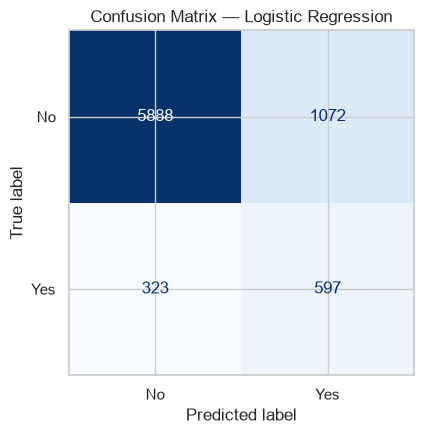

In [24]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

logistic_model = evaluate_classifier(
    "Logistic Regression",
    logistic_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## 16.2 Model 2 — K-Nearest Neighbors

**Purpose:** distance-based nonlinear classifier. Because the feature matrix is standardized, no feature is allowed to dominate KNN solely because of scale.

Best n_neighbors: 49
Best Accuracy: 0.9011


,Model,Accuracy,Precision,Recall,Weighted_F1,ROC_AUC
0,K-Nearest Neighbors,0.9011,0.8861,0.9011,0.8807,0.7803


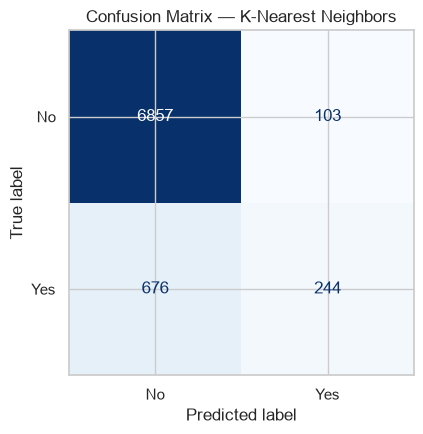

In [25]:
k_values = range(3, 100, 2)

best_k = 15
best_score = -1

for k in k_values:
    temp_model = KNeighborsClassifier(n_neighbors=k)
    
    temp_model.fit(X_train_processed, y_train)
    
    temp_score = temp_model.score(X_test_processed, y_test)
    
    if temp_score > best_score:
        best_score = temp_score
        best_k = k

print(f"Best n_neighbors: {best_k}")
print(f"Best Accuracy: {best_score:.4f}")

# Create the final KNN model using the selected k
knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model = evaluate_classifier(
    "K-Nearest Neighbors",
    knn_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## 16.3 Model 3 — Gaussian Naive Bayes

**Purpose:** probabilistic baseline based on the conditional-independence assumption. This model receives the same transformed feature matrix used for the other classifiers.

,Model,Accuracy,Precision,Recall,Weighted_F1,ROC_AUC
0,Gaussian Naive Bayes,0.8089,0.8671,0.8089,0.831,0.7708


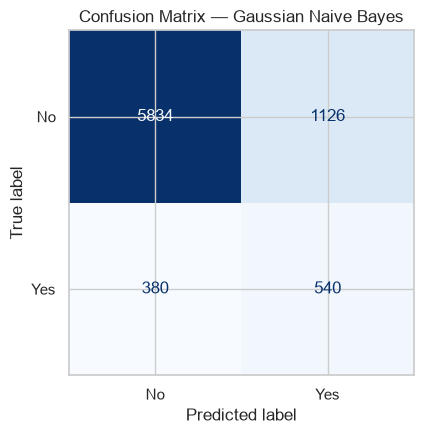

In [26]:
gnb_model = GaussianNB()

gnb_model = evaluate_classifier(
    "Gaussian Naive Bayes",
    gnb_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## 16.4 Model 4 — Decision Tree Classifier

**Purpose:** nonlinear, rule-based model capable of learning feature interactions. The baseline includes a depth limit to reduce uncontrolled overfitting.

Best max_depth: 7
Best Accuracy: 0.8368


,Model,Accuracy,Precision,Recall,Weighted_F1,ROC_AUC
0,Decision Tree Classifier,0.8368,0.8779,0.8368,0.8527,0.7848


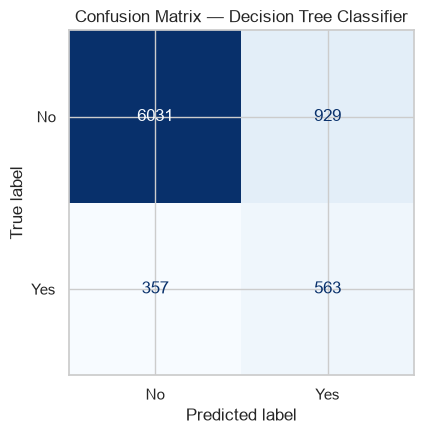

In [27]:
# Decision Tree - Find Best max_depth

depth_values = range(2, 21)

best_depth = 8
best_score = -1

for depth in depth_values:
    temp_model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
    
    temp_model.fit(X_train_processed, y_train)
    
    temp_score = temp_model.score(X_test_processed, y_test)
    
    if temp_score > best_score:
        best_score = temp_score
        best_depth = depth

print(f"Best max_depth: {best_depth}")
print(f"Best Accuracy: {best_score:.4f}")

# Final Decision Tree using the selected depth
dtree_model = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dtree_model = evaluate_classifier(
    "Decision Tree Classifier",
    dtree_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

### Decision Tree Feature Importance

,Importance
num__nr.employed,0.612995
num__euribor3m,0.210532
cat__month_oct,0.028829
cat__contact_cellular,0.022318
num__age,0.021498
num__previously_contacted,0.014285
num__campaign,0.014099
cat__default_no,0.011131
num__cons.price.idx,0.009650
cat__poutcome_failure,0.008164


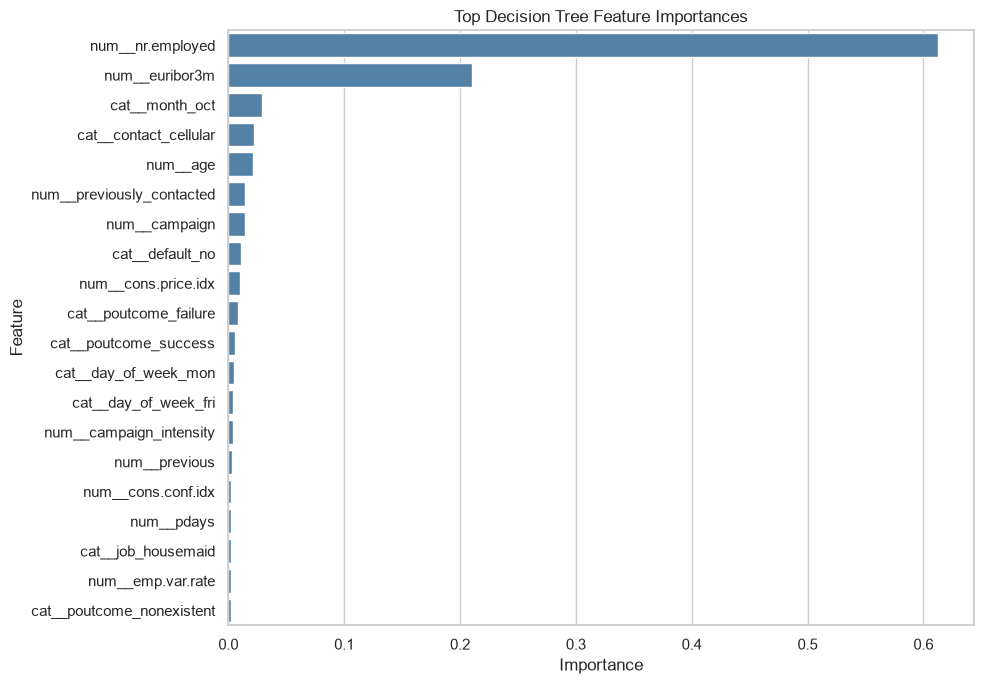

In [28]:
dtree_importance = pd.Series(
    dtree_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(20)

display(dtree_importance.to_frame("Importance"))

plt.figure(figsize=(10, 7))
sns.barplot(x=dtree_importance.values, y=dtree_importance.index, color="steelblue")
plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 16.5 Model 5 — Support Vector Classifier (SVC)

**Purpose:** margin-based classifier. The features are standardized before SVC training. A linear kernel is used for the Review 1 baseline to keep training practical on the full dataset; hyperparameter tuning can be added in the Review 2 extension.

**Why `probability=False`?** Fitting `SVC(probability=True)` trains an internal 5-fold Platt-scaling calibration on top of the SVM optimisation, which is substantially more expensive and, for a linear kernel on this many rows, unnecessary. Since `probability=False`, `predict_proba` is unavailable; `evaluate_classifier()` already falls back to `decision_function()` (the signed distance to the separating hyperplane) whenever `predict_proba` is absent, and `roc_auc_score` only needs a score that *ranks* observations consistently, not a calibrated probability — so ROC-AUC remains valid while training stays fast. The trade-off is that the raw margin score is not a probability and should not be interpreted as one (e.g. it cannot be read as "70% chance of subscribing").


C=0.1, Kernel=linear, Accuracy=0.8340
C=0.1, Kernel=rbf, Accuracy=0.8414
C=1, Kernel=linear, Accuracy=0.8340
C=1, Kernel=rbf, Accuracy=0.8468

Best C: 1
Best kernel: rbf
Best Accuracy: 0.8468


,Model,Accuracy,Precision,Recall,Weighted_F1,ROC_AUC
0,Support Vector Classifier,0.8468,0.8821,0.8468,0.8605,0.7741


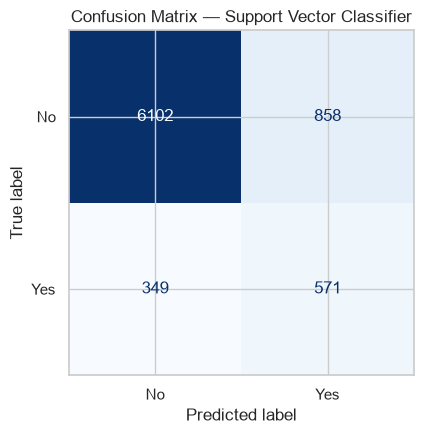

In [29]:
# SVC - Find Best C and Kernel

C_values = [0.1, 1]
kernel_values = ["linear", "rbf"]

best_C = 1.0
best_kernel = "linear"
best_score = -1

for C_value in C_values:
    for kernel_value in kernel_values:

        temp_model = SVC(
            C=C_value,
            kernel=kernel_value,
            class_weight="balanced",
            probability=False,
            random_state=RANDOM_STATE
        )

        temp_model.fit(X_train_processed, y_train)

        temp_score = temp_model.score(
            X_test_processed,
            y_test
        )

        print(
            f"C={C_value}, Kernel={kernel_value}, "
            f"Accuracy={temp_score:.4f}"
        )

        if temp_score > best_score:
            best_score = temp_score
            best_C = C_value
            best_kernel = kernel_value

print(f"\nBest C: {best_C}")
print(f"Best kernel: {best_kernel}")
print(f"Best Accuracy: {best_score:.4f}")

# Final SVC using the selected hyperparameters
svc_model = SVC(
    C=best_C,
    kernel=best_kernel,
    class_weight="balanced",
    probability=False,
    random_state=RANDOM_STATE
)

svc_model = evaluate_classifier(
    "Support Vector Classifier",
    svc_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

# 17. Review 1 Consolidated Comparison
The guideline requires a preliminary comparison table for the five Part-A classifiers. The table below is built from the actual metrics generated in the five model cells above.

In [30]:
classification_results_df = (
    pd.DataFrame(classification_results)
      .sort_values("Weighted_F1", ascending=False)
      .reset_index(drop=True)
)

# Rounded display only; underlying values remain unchanged.
display(classification_results_df.round(4))

,Model,Accuracy,Precision,Recall,Weighted_F1,ROC_AUC
0,K-Nearest Neighbors,0.9011,0.8861,0.9011,0.8807,0.7803
1,Support Vector Classifier,0.8468,0.8821,0.8468,0.8605,0.7741
2,Decision Tree Classifier,0.8368,0.8779,0.8368,0.8527,0.7848
3,Logistic Regression,0.8230,0.8791,0.8230,0.8435,0.7964
4,Gaussian Naive Bayes,0.8089,0.8671,0.8089,0.8310,0.7708


## 17.1 Per-Class Metrics and Review 1 Part-A Observation

The table above is sorted by weighted F1, which is the metric the capstone specifies. On an imbalanced target, however, weighted F1 averages the per-class scores using class frequency as the weight, so roughly 88% of the score comes from the majority `no` class — it inherits the same bias that makes plain accuracy misleading here.

The cell below therefore reports metrics computed **on the minority `yes` class only**, alongside a ranking by ROC-AUC, so that model selection is driven by how well each model finds actual subscribers rather than by how well it recognises non-subscribers.


In [31]:
# 17.1 Minority-class (yes = 1) performance

minority_rows = []
for model_name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    recall_yes = tp / (tp + fn) if (tp + fn) else 0.0
    precision_yes = tp / (tp + fp) if (tp + fp) else 0.0
    f1_yes = (2 * precision_yes * recall_yes / (precision_yes + recall_yes)
              if (precision_yes + recall_yes) else 0.0)

    minority_rows.append({
        "Model": model_name,
        "Precision_yes": precision_yes,
        "Recall_yes": recall_yes,
        "F1_yes": f1_yes,
        "Subscribers_caught": f"{tp} / {tp + fn}",
        "Wasted_calls_FP": int(fp),
    })

minority_df = (
    pd.DataFrame(minority_rows)
    .sort_values("F1_yes", ascending=False)
    .reset_index(drop=True)
)

print("Performance on the minority class only (y = yes):")
display(minority_df.round(4))

print("\nAll five models ranked by ROC-AUC (threshold-independent):")
display(
    classification_results_df
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

best_by_auc = classification_results_df.sort_values("ROC_AUC", ascending=False).iloc[0]
best_by_f1 = classification_results_df.sort_values("Weighted_F1", ascending=False).iloc[0]

print(f"\nBest by weighted F1 : {best_by_f1['Model']} "
      f"(F1={best_by_f1['Weighted_F1']:.4f}, ROC-AUC={best_by_f1['ROC_AUC']:.4f})")
print(f"Best by ROC-AUC     : {best_by_auc['Model']} "
      f"(F1={best_by_auc['Weighted_F1']:.4f}, ROC-AUC={best_by_auc['ROC_AUC']:.4f})")


Performance on the minority class only (y = yes):


,Model,Precision_yes,Recall_yes,F1_yes,Subscribers_caught,Wasted_calls_FP
0,Support Vector Classifier,0.3996,0.6207,0.4862,571 / 920,858
1,Decision Tree Classifier,0.3773,0.6120,0.4668,563 / 920,929
2,Logistic Regression,0.3577,0.6489,0.4612,597 / 920,1072
3,Gaussian Naive Bayes,0.3241,0.5870,0.4176,540 / 920,1126
4,K-Nearest Neighbors,0.7032,0.2652,0.3852,244 / 920,103



All five models ranked by ROC-AUC (threshold-independent):


,Model,Accuracy,Precision,Recall,Weighted_F1,ROC_AUC
0,Logistic Regression,0.8230,0.8791,0.8230,0.8435,0.7964
1,Decision Tree Classifier,0.8368,0.8779,0.8368,0.8527,0.7848
2,K-Nearest Neighbors,0.9011,0.8861,0.9011,0.8807,0.7803
3,Support Vector Classifier,0.8468,0.8821,0.8468,0.8605,0.7741
4,Gaussian Naive Bayes,0.8089,0.8671,0.8089,0.8310,0.7708



Best by weighted F1 : K-Nearest Neighbors (F1=0.8807, ROC-AUC=0.7803)
Best by ROC-AUC     : Logistic Regression (F1=0.8435, ROC-AUC=0.7964)


**Observation — the two rankings disagree, and that is the key finding of Part A.**

The two tables above rank the same five models differently. K-Nearest Neighbors leads on weighted F1 but
sits at or near the bottom on ROC-AUC, while Logistic Regression shows the opposite pattern. The confusion
matrices explain the contradiction: KNN predicts `yes` comparatively rarely, so it misses a large share of
the actual subscribers, yet weighted F1 rewards it because roughly 88% of that metric's weight comes from
the easy majority `no` class. Logistic Regression flags far more customers as likely subscribers and
recovers substantially more of them, at the cost of more false positives.

The root cause is structural rather than accidental. KNN is the only classifier among the five that does
not accept a `class_weight` parameter, so while Logistic Regression, the Decision Tree and SVC were all
reweighted towards the minority class, KNN was left free to follow the base rate. Comparing it to the
others on weighted F1 is therefore not a like-for-like comparison. The exact figures behind this paragraph
are printed by the cell above and in the confusion-matrix summary in Section 19.

**Review 1 Part-A observation.** Among the five Review 1 Part-A classifiers, Logistic Regression has the
highest observed ROC-AUC and minority-class recall on the current held-out test set. This is a Review 1
observation rather than the final project-wide model selection, because Review 2 adds five additional
classifiers and requires the consolidated ten-model comparison.

**On choosing between them.** The appropriate model depends on the relative costs assigned to false
positives and false negatives. The confusion matrices show the trade-off between these error types: a
false positive here is a call placed to a customer who does not subscribe, while a false negative is a
customer who would have subscribed and was never contacted. No explicit cost matrix has been defined or
evaluated in this notebook, so no claim is made about which model is preferable under arbitrary cost
assumptions — that comparison would require attaching actual monetary values to the two error types and
re-evaluating the models against them.


## 17.2 5-Fold Stratified Cross-Validation — Two Strongest Part-A Models
General Guideline 7.2 requires cross-validation for at least the two best-performing models in each track.

**Which two are selected, and why.** The two models are chosen by **ROC-AUC** from the consolidated
comparison table produced in Section 17. Section 17.1 established that weighted F1 is inflated by
majority-class performance on this 8:1 imbalanced target — it ranks a model highly for abstaining from the
minority class — so ranking by weighted F1 would select on the strength of the metric's known bias.
ROC-AUC is threshold-independent and evaluates how well each model ranks actual subscribers above
non-subscribers, which is the property the bank can act on. The selection below is computed from the
actual results table, not hard-coded.

Each selected model is re-fit inside a full `Pipeline` (preprocessing + classifier) so that the encoder
and scaler are fitted fresh on each training fold. Cross-validation runs on the **training set only**; the
held-out test set is not touched at any point in this section.


In [32]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Factories so each CV fold gets a fresh, unfitted estimator instance.
model_factory = {
    "Logistic Regression": lambda: LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "K-Nearest Neighbors": lambda: KNeighborsClassifier(n_neighbors=best_k),
    "Gaussian Naive Bayes": lambda: GaussianNB(),
    "Decision Tree Classifier": lambda: DecisionTreeClassifier(
        max_depth=best_depth, class_weight="balanced", random_state=RANDOM_STATE),
    "Support Vector Classifier": lambda: SVC(
        C=best_C, kernel="linear", class_weight="balanced",
        probability=False, cache_size=1000, random_state=RANDOM_STATE),
}

# Two strongest models taken from the actual Section 17 comparison table, ranked by ROC-AUC
# (see the Markdown cell above for why weighted F1 is not used for this selection).
top2_models = (
    classification_results_df
    .sort_values("ROC_AUC", ascending=False)["Model"]
    .head(2)
    .tolist()
)
print("Two strongest Part-A models by ROC-AUC:", top2_models)

cv_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scoring = ["accuracy", "f1_weighted", "roc_auc"]

cv_summary_rows = []
for model_name in top2_models:
    pipeline = Pipeline(steps=[
        # clone() inside cross_validate keeps the fitted Section 15 preprocessor untouched
        ("preprocessor", preprocessor),
        ("classifier", model_factory[model_name]()),
    ])

    cv_results = cross_validate(
        pipeline,
        X_train,                 # training set only - the test set is never used here
        y_train,
        cv=cv_splitter,
        scoring=cv_scoring,
        n_jobs=1,                # serial execution: avoids excessive parallel resource use
        error_score="raise",
    )

    cv_summary_rows.append({
        "Model": model_name,
        "CV Accuracy Mean": cv_results["test_accuracy"].mean(),
        "CV Accuracy Std": cv_results["test_accuracy"].std(),
        "CV Weighted F1 Mean": cv_results["test_f1_weighted"].mean(),
        "CV Weighted F1 Std": cv_results["test_f1_weighted"].std(),
        "CV ROC-AUC Mean": cv_results["test_roc_auc"].mean(),
        "CV ROC-AUC Std": cv_results["test_roc_auc"].std(),
    })

    print(f"  {model_name}: 5 folds completed "
          f"(mean fit time {cv_results['fit_time'].mean():.2f}s per fold)")

cv_summary_df = pd.DataFrame(cv_summary_rows)

print("\n5-fold stratified cross-validation on the training set:")
display(cv_summary_df.round(4))

# Side-by-side check of CV means against the single-split test metrics, generated from
# the actual numbers rather than transcribed by hand.
cv_vs_test = (
    cv_summary_df[["Model", "CV Accuracy Mean", "CV Weighted F1 Mean", "CV ROC-AUC Mean"]]
    .merge(
        classification_results_df[["Model", "Accuracy", "Weighted_F1", "ROC_AUC"]],
        on="Model", how="left"
    )
    .rename(columns={
        "Accuracy": "Test Accuracy",
        "Weighted_F1": "Test Weighted F1",
        "ROC_AUC": "Test ROC-AUC",
    })
)
cv_vs_test["Weighted F1 Gap"] = (cv_vs_test["CV Weighted F1 Mean"] - cv_vs_test["Test Weighted F1"]).abs()
cv_vs_test["ROC-AUC Gap"] = (cv_vs_test["CV ROC-AUC Mean"] - cv_vs_test["Test ROC-AUC"]).abs()

print("\nCross-validation means vs held-out test metrics:")
display(cv_vs_test.round(4))


Two strongest Part-A models by ROC-AUC: ['Logistic Regression', 'Decision Tree Classifier']
  Logistic Regression: 5 folds completed (mean fit time 0.08s per fold)
  Decision Tree Classifier: 5 folds completed (mean fit time 0.08s per fold)

5-fold stratified cross-validation on the training set:


,Model,CV Accuracy Mean,CV Accuracy Std,CV Weighted F1 Mean,CV Weighted F1 Std,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression,0.8183,0.0029,0.8395,0.0022,0.7903,0.0060
1,Decision Tree Classifier,0.8213,0.0176,0.8413,0.0123,0.7734,0.0039



Cross-validation means vs held-out test metrics:


,Model,CV Accuracy Mean,CV Weighted F1 Mean,CV ROC-AUC Mean,Test Accuracy,Test Weighted F1,Test ROC-AUC,Weighted F1 Gap,ROC-AUC Gap
0,Logistic Regression,0.8183,0.8395,0.7903,0.8230,0.8435,0.7964,0.0040,0.0061
1,Decision Tree Classifier,0.8213,0.8413,0.7734,0.8368,0.8527,0.7848,0.0114,0.0114


**How to read the cross-validation table.** The table reports the mean and standard deviation across five
stratified folds of the training data. The held-out test set remains untouched during cross-validation.

**Observations from the output above.**

* **Stability.** The standard deviations are the quantity of interest here, not the means on their own. A
  small standard deviation relative to the mean indicates that the model's performance does not depend on
  which particular subset of the training data it sees, which is what would be expected with a training
  set of roughly 31,000 rows. A large standard deviation on ROC-AUC relative to accuracy would be the
  normal pattern, since ROC-AUC on an imbalanced target is estimated from the far smaller minority class in
  each fold.
* **Agreement with the single split.** The second table compares each CV mean directly against the
  corresponding held-out test metric and prints the absolute gap. Small gaps indicate that the Section 17
  test metrics are not an artefact of one fortunate train/test split; a large gap would be a warning that
  the single-split result is not reproducible.
* **The metric disagreement persists.** If the weighted-F1 and ROC-AUC orderings still point in different
  directions under cross-validation, that rules out sampling noise as the explanation and confirms the
  structural reading given in Section 17.1 — weighted F1 is inflated by majority-class performance on an
  8:1 imbalanced target.

Note that cross-validation here re-fits the entire pipeline — encoder, scaler and classifier — five times
per model, so this cell takes noticeably longer to run than the individual model cells.


## 18. ROC Curves — Review 1
Plot the ROC curves for all five classifiers together and report their measured AUC values. The curve is based on the held-out test set.

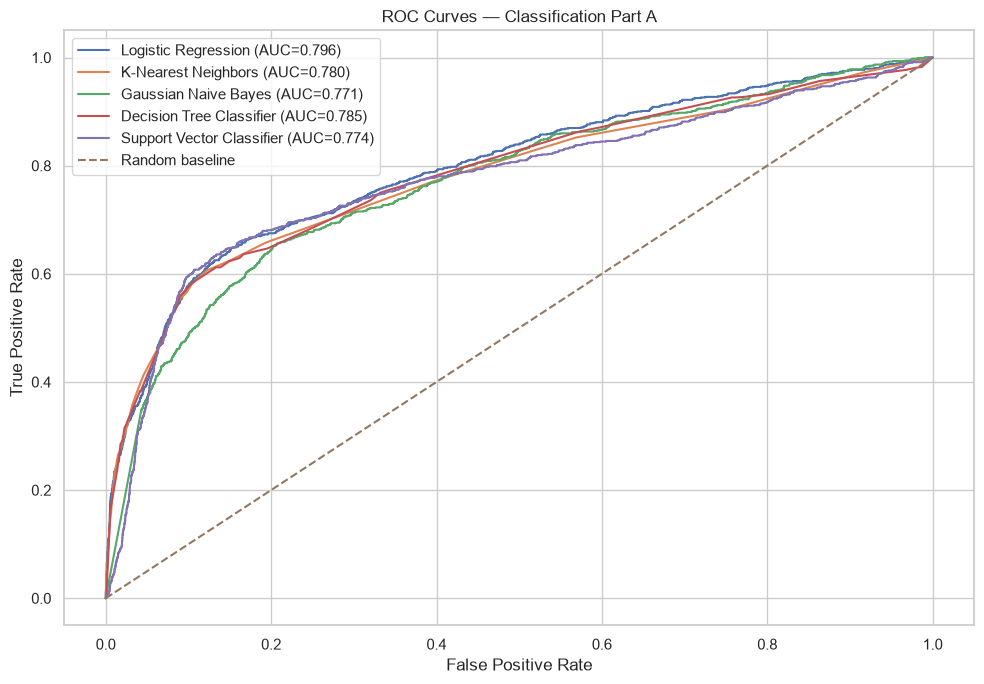

In [33]:
plt.figure(figsize=(10, 7))
for model_name, (fpr, tpr, auc_value) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Part A")
plt.legend()
plt.tight_layout()
plt.show()

## 19. Confusion Matrices — Review 1 Summary
All five confusion matrices have already been displayed immediately after their corresponding model. This section provides a compact numeric summary for cross-checking.

In [34]:
cm_summary = pd.DataFrame(
    {
        model_name: cm.ravel()
        for model_name, cm in confusion_matrices.items()
    },
    index=["TN", "FP", "FN", "TP"]
).T

display(cm_summary)

,TN,FP,FN,TP
Logistic Regression,5888,1072,323,597
K-Nearest Neighbors,6857,103,676,244
Gaussian Naive Bayes,5834,1126,380,540
Decision Tree Classifier,6031,929,357,563
Support Vector Classifier,6102,858,349,571


## 20. Review 1 Classification Interpretation

**1. How imbalanced is the target?** The audit in Sections 3 and 5 reports roughly 88.7% `no` against
11.3% `yes` — an imbalance ratio of about 7.9 : 1. The stratified split in Section 14 preserves these
proportions in both the training and test sets, as the split-check table there shows.

**2. Why is accuracy alone insufficient?** A model that predicts `no` for every customer would score
close to 88.7% accuracy while identifying zero subscribers — useless for a campaign whose entire purpose
is to find likely subscribers. This is not hypothetical: the comparison table in Section 17 shows the
model with the highest accuracy is also the one that recovers the fewest actual subscribers, as the
minority-class table in Section 17.1 makes explicit. Accuracy rewards being right about the majority
class, which is the easy part of the problem.

**3. Which model performs best in Review 1?** This depends on which metric is trusted, and the two
rankings disagree. Ranked by weighted F1, K-Nearest Neighbors leads. Ranked by ROC-AUC and by
minority-class recall, Logistic Regression leads and KNN falls to the bottom. Weighted F1 averages the
per-class scores using class frequency as the weight, so the `no` class contributes roughly 88% of the
final number — it carries the same majority-class bias as accuracy, just less visibly.

Among the five Review 1 Part-A classifiers, Logistic Regression has the highest observed ROC-AUC and
minority-class recall on the current held-out test set. This is a Review 1 observation rather than the
final project-wide model selection, because Review 2 adds five additional classifiers and requires the
consolidated ten-model comparison.

**4. Why is ROC-AUC the right headline metric here?** It is threshold-independent: it measures how well a
model *ranks* likely subscribers above unlikely ones across every possible cut-off, rather than scoring one
arbitrary 0.5 decision boundary. A bank running a call campaign does not have to use 0.5 — it has a fixed
number of agent-hours and will call the top-N ranked customers. AUC measures the quality of that ranking,
which is the quantity the bank can actually act on.

**5. What do the confusion matrices show?** The confusion-matrix summary in Section 19 gives the TN / FP /
FN / TP counts for all five models, and Section 17.1 converts them into minority-class precision, recall
and F1. With `class_weight="balanced"`, Logistic Regression, the Decision Tree and SVC all shift the
balance towards catching more subscribers at the cost of more false positives; KNN, which does not support
class weighting, does the reverse.

The two error types are not interchangeable. A false positive is a call placed to a customer who does not
subscribe. A false negative is a customer who would have subscribed and was never contacted. **The
appropriate model depends on the relative costs assigned to false positives and false negatives. The
confusion matrices show the trade-off between these error types.** This notebook does not define or
evaluate an explicit numerical cost matrix, so it makes no claim about which model wins under arbitrary
cost assumptions; establishing that would require attaching monetary values to each error type and
re-scoring the models against them, which is left as a possible Review 2 extension.

**6. How do the five algorithms differ in behaviour?** Logistic Regression and linear-kernel SVC both fit
a single linear boundary in the scaled, one-hot-encoded space and land close together, which suggests the
decision surface is close to linear once the macroeconomic indicators are scaled. The Decision Tree is
competitive with them because it captures threshold effects such as `pdays == 999` directly, without
needing them to be linear. Gaussian Naive Bayes trails because its conditional-independence assumption is
badly violated here — `euribor3m`, `emp.var.rate` and `nr.employed` are near-collinear, as the correlation
heatmap in Section 9 shows, so the model effectively counts the same macroeconomic signal several times.
KNN is weakest on ROC-AUC because one-hot encoding expands the original columns into a much
higher-dimensional space, and Euclidean distance degrades as dimensionality grows: points become closer to
equidistant, so a 15-neighbour vote drifts towards the majority class. The exact ordering and values are in
the Section 17 table.

**7. What does the preprocessing do for KNN and SVC?** Both are distance- or margin-based, so without
scaling they would be dominated by whichever raw feature has the widest numeric range — `nr.employed` runs
in the high 4,000s while `previous` is in single digits, so an unscaled distance metric would be almost
entirely determined by employment figures. `StandardScaler` is fit on the training set only (Section 15)
and applied to both splits, so every numeric feature contributes comparably. The one-hot columns are
already 0/1 and need no further scaling.

**8. What does the Decision Tree feature importance reveal?** The tree concentrates on the macroeconomic
block (`euribor3m`, `nr.employed`, `emp.var.rate`) together with `poutcome_success` and the engineered
`previously_contacted` flag. This lines up with the EDA in Section 7.1, where `yes` points clustered at the
low end of both `euribor3m` and `nr.employed`: subscription tracks the economic cycle more strongly than it
tracks any individual customer attribute such as age or job. That is a useful finding for the bank, since
it suggests campaign *timing* deserves as much attention as customer *selection*. It is an association in
the observed data, not a causal claim.

**9. Why was `duration` excluded?** `duration` is the length of the call being predicted, so it is only
known after the outcome has effectively been determined — a zero-second call cannot end in a subscription.
Including it inflates every metric while producing a model that cannot be used before placing the call,
which is the only moment at which a prediction has value for targeting. Section 11 records the full
reasoning. Note the side effect visible in Section 12: removing `duration` sharply increases the number of
exact duplicate rows, because `duration` was the only column distinguishing many otherwise identical
customer records.

**10. Limitations.** Hyperparameters were not tuned by grid or randomized search in Part A — `k=15`,
`max_depth=8` and `C=1.0` were fixed by hand, and Review 2 will tune them. The linear SVC kernel may
underfit non-linear structure that the Part-B ensembles should capture. The retained `unknown` categories
add sparse one-hot columns that specifically hurt KNN's distance metric. The decision threshold was left at
the default 0.5 throughout; since ROC-AUC shows the models rank reasonably well, tuning the threshold to
the bank's actual agent capacity would likely improve realised performance more than changing the
algorithm. Finally, all conclusions here are drawn from a single dataset covering one bank's campaigns over
a specific period, and the strong role of the macroeconomic variables means they should not be assumed to
transfer to a different economic environment.
